## 0. Imports & Setup

In [112]:

import os, json, re, math, random, collections, itertools, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)
os.makedirs('embeddings', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
print("Directories ready.")


Device: cpu
Directories ready.


## 1. Load Data

In [113]:

# Load cleaned.txt
with open('cleaned.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Parse article boundaries [N] and map to article text
article_pattern = re.compile(r'\[(\d+)\]\s*(.*?)(?=\[\d+\]|$)', re.DOTALL)
articles_raw = {int(m.group(1)): m.group(2).strip() for m in article_pattern.finditer(raw_text)}
print(f"Total articles in cleaned.txt: {len(articles_raw)}")

# Load Metadata.json
with open('Metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)
print(f"Total metadata entries: {len(metadata)}")
print("Sample entry:", list(metadata.items())[0])


Total articles in cleaned.txt: 250
Total metadata entries: 250
Sample entry: ('1', {'title': '’ہم دوبارہ لڑنا نہیں چاہتے‘: بنگلہ دیش کے انتخابات میں کامیابی کے بعد طارق رحمان کو درپیش چیلنجز', 'publish_date': '2026-02-15'})


## 2. Tokenisation

In [114]:

def urdu_tokenize(text):
    """Tokenizes Urdu text while preserving punctuation as separate tokens."""
    # Match punctuation OR contiguous word characters
    token_pattern = re.compile(r'([،۔؟!.,;:()\'"\[\]{}]|\w+)')
    tokens = token_pattern.findall(text)
    return [t.strip() for t in tokens if t.strip()]

# Tokenize all articles
all_tokens_per_article = {aid: urdu_tokenize(txt) for aid, txt in articles_raw.items()}
all_tokens_flat = [t for toks in all_tokens_per_article.values() for t in toks]
print(f"Total tokens (flat): {len(all_tokens_flat)}")
print(f"Unique tokens: {len(set(all_tokens_flat))}")


Total tokens (flat): 419677
Unique tokens: 13993


---
# Part 1: Word Embeddings (25 Marks)

### 1.1 Vocabulary (Top 10,000 Tokens)

In [115]:
VOCAB_SIZE = 10_000
UNK = '<UNK>'
PAD = '<PAD>'

counter = collections.Counter(all_tokens_flat)
most_common = counter.most_common(VOCAB_SIZE)
vocab = [w for w, _ in most_common]

# Reserve 0=<UNK>, 1=<PAD> — real words start at index 2
word2idx = {UNK: 0, PAD: 1}
for w in vocab:
    word2idx[w] = len(word2idx)
idx2word = {i: w for w, i in word2idx.items()}

def encode(token):
    return word2idx.get(token, 0)   # 0 = <UNK>

print(f"Vocabulary size (incl. UNK + PAD): {len(word2idx)}")
print(f"Top 10 tokens: {vocab[:10]}")
print(f"UNK idx={word2idx[UNK]}, PAD idx={word2idx[PAD]}, first real word idx={word2idx[vocab[0]]}")

Vocabulary size (incl. UNK + PAD): 10002
Top 10 tokens: ['کے', '۔', 'میں', 'کی', 'ہے', 'سے', 'اور', 'کہ', 'کا', 'نے']
UNK idx=0, PAD idx=1, first real word idx=2


### 1.2 TF-IDF Matrix

In [116]:

# Build term-document matrix
article_ids = sorted(articles_raw.keys())
N_docs = len(article_ids)
V = len(word2idx)  # vocab size incl UNK

print(f"Building TF-IDF for {N_docs} docs × {V} vocab...")

# Compute TF (term frequency) per document
# tf_matrix shape: (V, N_docs)
tf_matrix = np.zeros((V, N_docs), dtype=np.float32)
for j, aid in enumerate(article_ids):
    toks = all_tokens_per_article[aid]
    total = len(toks) if toks else 1
    for t in toks:
        idx = encode(t)
        tf_matrix[idx, j] += 1.0 / total

# Document frequency
df = (tf_matrix > 0).sum(axis=1).astype(np.float32)  # shape (V,)

# IDF
idf = np.log(N_docs / (1.0 + df))  # shape (V,)

# TF-IDF
tfidf_matrix = tf_matrix * idf[:, np.newaxis]  # (V, N_docs)

np.save('embeddings/tfidf_matrix.npy', tfidf_matrix)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("Saved embeddings/tfidf_matrix.npy")


Building TF-IDF for 250 docs × 10002 vocab...
TF-IDF matrix shape: (10002, 250)
Saved embeddings/tfidf_matrix.npy


### 1.3 Top-10 Discriminative Words per Topic

Category distribution:
  politics: 176 articles
  sports: 18 articles
  economy: 7 articles
  crime: 33 articles
  lifestyle: 16 articles


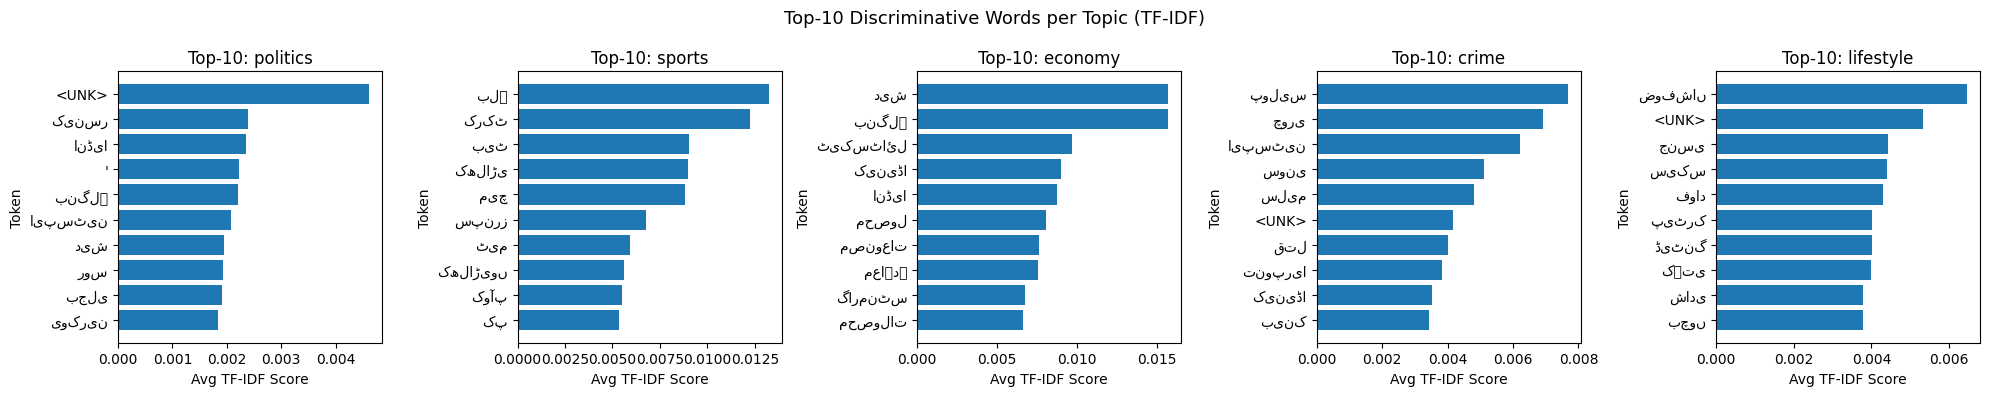

Figure saved.


In [117]:

# Define 5 categories from Metadata for topic assignment (same as Part 3)
CATEGORIES = {
    'politics':  ['سیاست','انتخاب','حکومت','پارلیمنٹ','وزیر','صدر','جماعت','ووٹ','اقتدار','سیاسی'],
    'sports':    ['کرکٹ','ٹیم','میچ','کھلاڑی','گول','فٹبال','اسکور','ٹورنامنٹ','بلے باز','باؤلر'],
    'economy':   ['روپیہ','معیشت','بازار','قیمت','تجارت','سرمایہ','بینک','مہنگائی','برآمد','درآمد'],
    'crime':     ['پولیس','گرفتار','ملزم','چوری','جرم','عدالت','مقدمہ','قتل','تفتیش','مجرم'],
    'lifestyle': ['زندگی','خاندان','شادی','بچے','گھر','خواتین','صحت','تعلیم','معاشرہ','ثقافت'],
}

def assign_category(title):
    title_lower = title
    for cat, kws in CATEGORIES.items():
        if any(kw in title_lower for kw in kws):
            return cat
    return 'politics'  # default

# Assign categories to articles via metadata
art_category = {}
for aid_str, meta in metadata.items():
    aid = int(aid_str)
    art_category[aid] = assign_category(meta['title'])

cat_names = list(CATEGORIES.keys())
cat_to_doc_indices = {c: [] for c in cat_names}
for j, aid in enumerate(article_ids):
    cat = art_category.get(aid, 'politics')
    cat_to_doc_indices[cat].append(j)

print("Category distribution:")
for c, idxs in cat_to_doc_indices.items():
    print(f"  {c}: {len(idxs)} articles")

# Top-10 discriminative words per category (avg TF-IDF across category docs)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, cat in enumerate(cat_names):
    idxs = cat_to_doc_indices[cat]
    if not idxs:
        continue
    avg_tfidf = tfidf_matrix[:, idxs].mean(axis=1)  # (V,)
    top10_idx = np.argsort(avg_tfidf)[::-1][:10]
    top10_words = [idx2word[ii] for ii in top10_idx]
    top10_scores = avg_tfidf[top10_idx]
    axes[i].barh(top10_words[::-1], top10_scores[::-1])
    axes[i].set_title(f'Top-10: {cat}')
    axes[i].set_xlabel('Avg TF-IDF Score')
    axes[i].set_ylabel('Token')
plt.suptitle('Top-10 Discriminative Words per Topic (TF-IDF)', fontsize=13)
plt.tight_layout()
plt.savefig('embeddings/tfidf_top_words.png', dpi=100)
plt.show()
print("Figure saved.")


### 1.4 PPMI Matrix

In [118]:
WINDOW_K = 5
PPMI_VOCAB = min(10_000, len(word2idx) - 2)   # exclude UNK(0) and PAD(1)
print(f"Building co-occurrence matrix (window={WINDOW_K}) for top {PPMI_VOCAB} tokens...")

ppmi_words = [idx2word[i] for i in range(2, PPMI_VOCAB + 2)]   # indices 2..10001
ppmi_w2i   = {w: i for i, w in enumerate(ppmi_words)}
PV = len(ppmi_words)

cooc = np.zeros((PV, PV), dtype=np.float32)
total_pairs = 0

for toks in all_tokens_per_article.values():
    encoded = [ppmi_w2i[t] for t in toks if t in ppmi_w2i]
    for ci, c in enumerate(encoded):
        start = max(0, ci - WINDOW_K)
        end   = min(len(encoded), ci + WINDOW_K + 1)
        for oi in range(start, end):
            if oi != ci:
                cooc[c, encoded[oi]] += 1
                total_pairs += 1

print(f"Total co-occurrence pairs recorded: {total_pairs}")

# PPMI
row_sum  = cooc.sum(axis=1, keepdims=True)
col_sum  = cooc.sum(axis=0, keepdims=True)
total    = cooc.sum()

row_prob   = row_sum  / (total + 1e-10)
col_prob   = col_sum  / (total + 1e-10)
joint_prob = cooc     / (total + 1e-10)

with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2(joint_prob / (row_prob * col_prob + 1e-10) + 1e-10)

ppmi_matrix = np.maximum(0, pmi)

np.save('embeddings/ppmi_matrix.npy', ppmi_matrix)
print(f"PPMI matrix shape: {ppmi_matrix.shape}")
print("Saved embeddings/ppmi_matrix.npy")

Building co-occurrence matrix (window=5) for top 10000 tokens...
Total co-occurrence pairs recorded: 4149340
PPMI matrix shape: (10000, 10000)
Saved embeddings/ppmi_matrix.npy


### 1.5 t-SNE Visualization (200 Most Frequent Tokens)

Running t-SNE...


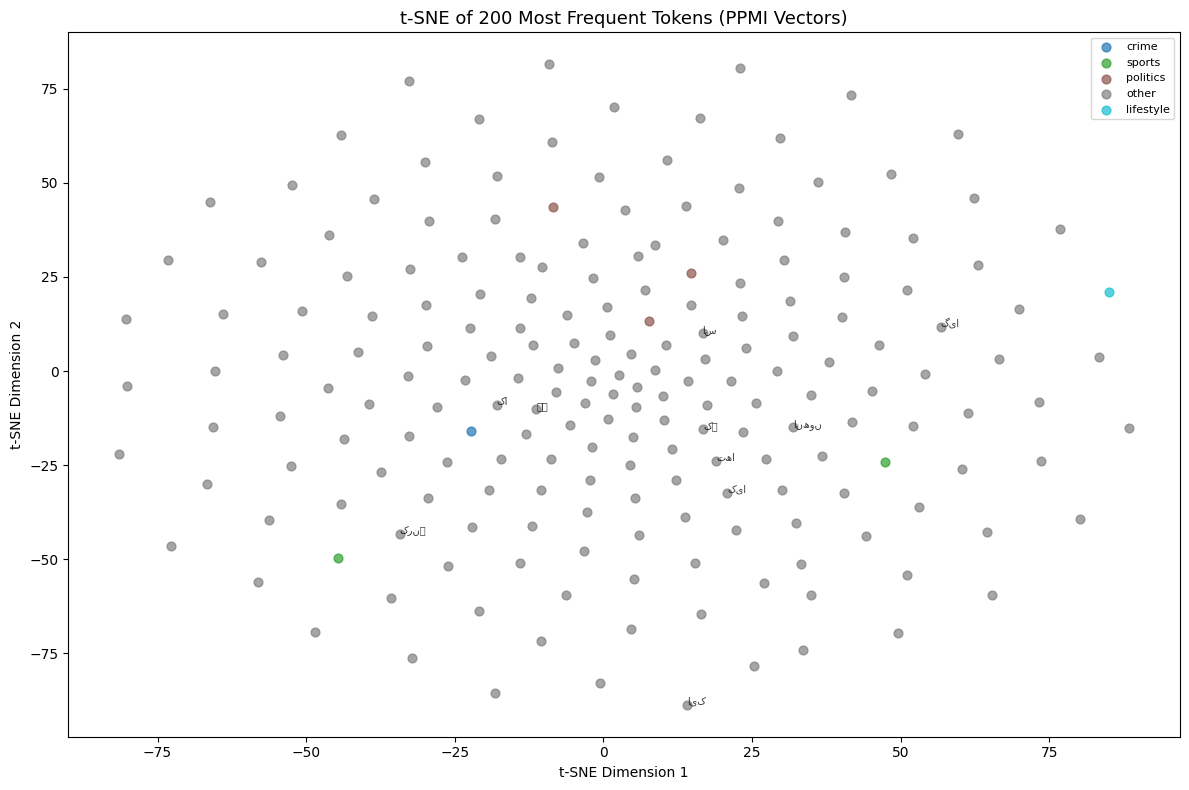

t-SNE figure saved.


In [119]:
TOP_N_TSNE = 200
tsne_words = ppmi_words[:TOP_N_TSNE]
tsne_vecs = ppmi_matrix[:TOP_N_TSNE]

def word_cat(w):
    for cat, kws in CATEGORIES.items():
        if w in kws:
            return cat
    return 'other'

tsne_cats = [word_cat(w) for w in tsne_words]
unique_cats = list(set(tsne_cats))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_color = {c: colors[i] for i, c in enumerate(unique_cats)}

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)  # fixed: n_iter → max_iter
tsne_result = tsne.fit_transform(tsne_vecs)

fig, ax = plt.subplots(figsize=(12, 8))
for cat in unique_cats:
    idxs = [i for i, c in enumerate(tsne_cats) if c == cat]
    ax.scatter(tsne_result[idxs, 0], tsne_result[idxs, 1],
               c=[cat_color[cat]], label=cat, alpha=0.7, s=40)

for i in range(0, min(40, TOP_N_TSNE), 4):
    ax.annotate(tsne_words[i], tsne_result[i], fontsize=7, alpha=0.8)

ax.set_title('t-SNE of 200 Most Frequent Tokens (PPMI Vectors)', fontsize=13)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('embeddings/ppmi_tsne.png', dpi=100)
plt.show()
print("t-SNE figure saved.")

### 1.6 Top-5 Nearest Neighbours (Cosine Similarity, PPMI)

In [120]:

def cosine_nn(matrix, w2i, i2w, query_word, top_k=5):
    if query_word not in w2i:
        return []
    idx = w2i[query_word]
    vec = matrix[idx]
    norm_vec = vec / (np.linalg.norm(vec) + 1e-10)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-10
    sims = (matrix / norms) @ norm_vec
    sims[idx] = -1  # exclude self
    top_idxs = np.argsort(sims)[::-1][:top_k]
    return [(i2w[i], float(sims[i])) for i in top_idxs]

ppmi_i2w = {i: w for w, i in ppmi_w2i.items()}

# Query 10 representative Urdu words
query_words_ppmi = ppmi_words[:10]  # top 10 most frequent
print("Top-5 Nearest Neighbours (PPMI, Cosine Similarity):")
print("-" * 60)
for qw in query_words_ppmi:
    nns = cosine_nn(ppmi_matrix, ppmi_w2i, ppmi_i2w, qw)
    nn_str = ', '.join([f"{w}({s:.3f})" for w, s in nns])
    print(f"{qw:20s} → {nn_str}")


Top-5 Nearest Neighbours (PPMI, Cosine Similarity):
------------------------------------------------------------
کے                   → میں(0.347), لیے(0.319), اور(0.314), بعد(0.294), مطابق(0.294)
۔                    → ہے(0.402), ہیں(0.382), کا(0.305), نے(0.303), اس(0.300)
میں                  → کے(0.347), اور(0.318), کی(0.310), ۔(0.299), ایک(0.297)
کی                   → اور(0.323), میں(0.310), سے(0.288), کے(0.277), ہے(0.267)
ہے                   → ۔(0.402), کہ(0.372), کا(0.345), یہ(0.326), کی(0.267)
سے                   → کی(0.288), اور(0.275), کے(0.270), ۔(0.262), اس(0.253)
اور                  → ،(0.417), کی(0.323), میں(0.318), کے(0.314), کو(0.313)
کہ                   → کہنا(0.378), ہے(0.372), کہا(0.348), نے(0.335), ہیں(0.319)
کا                   → ہے(0.345), کہنا(0.321), کہ(0.307), ۔(0.305), تھا(0.283)
نے                   → انھوں(0.367), کہا(0.352), کہ(0.335), ۔(0.303), کے(0.279)


### 1.7 Skip-gram Word2Vec Training

In [121]:

# ── Dataset ──────────────────────────────────────────────────────────────────
class SkipGramDataset(Dataset):
    def __init__(self, articles, w2i, window=5):
        self.pairs = []
        for toks in articles.values():
            encoded = [w2i.get(t, 0) for t in toks]
            for ci, c in enumerate(encoded):
                start = max(0, ci - window)
                end = min(len(encoded), ci + window + 1)
                for oi in range(start, end):
                    if oi != ci:
                        self.pairs.append((c, encoded[oi]))
        self.pairs = np.array(self.pairs, dtype=np.int64)

    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i, 0], self.pairs[i, 1]

# ── Model ─────────────────────────────────────────────────────────────────────
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.center  = nn.Embedding(vocab_size, embed_dim, sparse=True)
        self.context = nn.Embedding(vocab_size, embed_dim, sparse=True)
        nn.init.uniform_(self.center.weight,  -0.1, 0.1)
        nn.init.uniform_(self.context.weight, -0.1, 0.1)

    def forward(self, center_ids, pos_ctx_ids, neg_ctx_ids):
        # center_ids : (B,)
        # pos_ctx_ids: (B,)
        # neg_ctx_ids: (B, K)
        vc  = self.center(center_ids)          # (B, D)
        uo  = self.context(pos_ctx_ids)        # (B, D)
        un  = self.context(neg_ctx_ids)        # (B, K, D)

        pos_score = torch.sum(vc * uo, dim=1)  # (B,)
        neg_score = torch.bmm(un, vc.unsqueeze(2)).squeeze(2)  # (B, K)

        loss = -F.logsigmoid(pos_score).mean()                - F.logsigmoid(-neg_score).mean()
        return loss

# ── Negative sampling distribution ───────────────────────────────────────────
word_freqs = np.array([counter.get(idx2word.get(i,'<UNK>'), 1)
                       for i in range(len(word2idx))], dtype=np.float64)
word_freqs = word_freqs ** 0.75
noise_dist = word_freqs / word_freqs.sum()

# ── Training ──────────────────────────────────────────────────────────────────
EMBED_DIM = 100
K_NEG     = 10
WINDOW_W2V = 5
BATCH_SIZE = 512
EPOCHS     = 5
LR         = 0.001

print("Building skip-gram dataset (this may take a minute)...")
sg_dataset = SkipGramDataset(all_tokens_per_article, word2idx, window=WINDOW_W2V)
sg_loader  = DataLoader(sg_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"Dataset size: {len(sg_dataset)} pairs | Batches: {len(sg_loader)}")

model_sg = SkipGram(len(word2idx), EMBED_DIM).to(DEVICE)
optimizer = torch.optim.SparseAdam(list(model_sg.parameters()), lr=LR)

epoch_losses = []
print("Training Skip-gram Word2Vec...")
for epoch in range(EPOCHS):
    total_loss = 0.0
    for step, (c_ids, p_ids) in enumerate(sg_loader):
        c_ids = c_ids.to(DEVICE)
        p_ids = p_ids.to(DEVICE)
        # Sample negatives
        neg = np.random.choice(len(word2idx), size=(len(c_ids), K_NEG), p=noise_dist)
        neg_ids = torch.tensor(neg, dtype=torch.long, device=DEVICE)

        optimizer.zero_grad()
        loss = model_sg(c_ids, p_ids, neg_ids)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if (step+1) % 500 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS}  Step {step+1}/{len(sg_loader)}  Loss {loss.item():.4f}")

    avg_loss = total_loss / len(sg_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1} done | Avg Loss: {avg_loss:.4f}")

print("Training complete.")


Building skip-gram dataset (this may take a minute)...
Dataset size: 4189270 pairs | Batches: 8183
Training Skip-gram Word2Vec...
  Epoch 1/5  Step 500/8183  Loss 1.3259
  Epoch 1/5  Step 1000/8183  Loss 1.2918
  Epoch 1/5  Step 1500/8183  Loss 1.2630
  Epoch 1/5  Step 2000/8183  Loss 1.2780
  Epoch 1/5  Step 2500/8183  Loss 1.2719
  Epoch 1/5  Step 3000/8183  Loss 1.2558
  Epoch 1/5  Step 3500/8183  Loss 1.2299
  Epoch 1/5  Step 4000/8183  Loss 1.2026
  Epoch 1/5  Step 4500/8183  Loss 1.2426
  Epoch 1/5  Step 5000/8183  Loss 1.2337
  Epoch 1/5  Step 5500/8183  Loss 1.2362
  Epoch 1/5  Step 6000/8183  Loss 1.2078
  Epoch 1/5  Step 6500/8183  Loss 1.2254
  Epoch 1/5  Step 7000/8183  Loss 1.2027
  Epoch 1/5  Step 7500/8183  Loss 1.2093
  Epoch 1/5  Step 8000/8183  Loss 1.1901
Epoch 1 done | Avg Loss: 1.2414
  Epoch 2/5  Step 500/8183  Loss 1.1746
  Epoch 2/5  Step 1000/8183  Loss 1.1745
  Epoch 2/5  Step 1500/8183  Loss 1.1855
  Epoch 2/5  Step 2000/8183  Loss 1.2039
  Epoch 2/5  Step 25

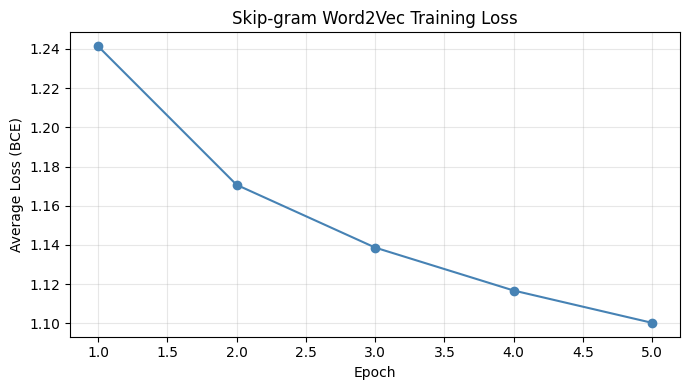

Embeddings saved: (10002, 100)
word2idx.json saved.


In [122]:

# Plot loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS+1), epoch_losses, marker='o', color='steelblue')
ax.set_title('Skip-gram Word2Vec Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Average Loss (BCE)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embeddings/w2v_loss_curve.png', dpi=100)
plt.show()

# Save averaged embeddings (center + context) / 2
center_emb  = model_sg.center.weight.detach().cpu().numpy()
context_emb = model_sg.context.weight.detach().cpu().numpy()
embeddings_w2v = (center_emb + context_emb) / 2.0
np.save('embeddings/embeddings_w2v.npy', embeddings_w2v)

# Save word2idx
with open('embeddings/word2idx.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False)

print(f"Embeddings saved: {embeddings_w2v.shape}")
print("word2idx.json saved.")


### 1.8 Nearest Neighbours (Word2Vec)

In [123]:

def w2v_nn(query_word, top_k=10):
    if query_word not in word2idx:
        return []
    idx = word2idx[query_word]
    vec = embeddings_w2v[idx]
    norm_vec = vec / (np.linalg.norm(vec) + 1e-10)
    norms = np.linalg.norm(embeddings_w2v, axis=1, keepdims=True) + 1e-10
    sims = (embeddings_w2v / norms) @ norm_vec
    sims[idx] = -1
    top_idxs = np.argsort(sims)[::-1][:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_idxs]

# 8 specific query words
query_words_w2v = ['پاکستان', 'حکومت', 'کرکٹ', 'عدالت', 'معیشت', 'پولیس', 'انتخاب', 'وزیر']
print("Top-10 Nearest Neighbours (Word2Vec):")
print("=" * 70)
for qw in query_words_w2v:
    nns = w2v_nn(qw)
    if nns:
        nn_str = ', '.join([f"{w}({s:.3f})" for w, s in nns])
        print(f"{qw:20s} → {nn_str}")
    else:
        print(f"{qw:20s} → (not in vocabulary)")


Top-10 Nearest Neighbours (Word2Vec):
پاکستان              → بورڈ(0.580), نیدرلینڈ(0.503), ایشیا(0.486), زیرانتظام(0.485), نقوی(0.480), انڈیا(0.478), کشمیر(0.472), ڈومیسٹک(0.471), ایکسپیٹس(0.469), ٹرافی(0.468)
حکومت                → طالبان(0.591), وفاقی(0.583), عبوری(0.559), فتوی(0.512), حکومتوں(0.464), افغان(0.461), وفاق(0.461), صوبائی(0.455), فوج(0.455), معتدل(0.453)
کرکٹ                 → کپ(0.630), کھیل(0.620), کھیلنے(0.612), بورڈ(0.607), بورڈز(0.606), ٹوئنٹی(0.593), کھیلنا(0.591), ورلڈ(0.587), فارمیٹ(0.586), ٹیم(0.582)
عدالت                → استدعا(0.729), مقدمے(0.665), جج(0.650), امتناع(0.625), کورٹ(0.613), فراڈ(0.613), درخواست(0.599), حکم(0.595), سماعت(0.592), پائیومبتی(0.581)
معیشت                → مستحکم(0.640), ترقی(0.621), مکالمے(0.571), استحکام(0.554), ویتنام(0.547), توانائی(0.541), شعبوں(0.538), ثقافتی(0.533), خودمختاری(0.527), نیٹو(0.526)
پولیس                → راجستھان(0.760), تھانے(0.657), ہریانہ(0.645), سپرنٹنڈنٹ(0.617), شکایت(0.611), نوہ(0.608), سٹیشن(0.594), اطلاع(0.

### 1.9 Word Analogy Tests

In [124]:
def analogy(word_a, word_b, word_c, top_k=5):
    """word_a : word_b :: word_c : ?   →  b - a + c"""
    for w in [word_a, word_b, word_c]:
        if w not in word2idx:
            return [], f"OOV: {w}"
    va = embeddings_w2v[word2idx[word_a]]
    vb = embeddings_w2v[word2idx[word_b]]
    vc = embeddings_w2v[word2idx[word_c]]
    target = vb - va + vc
    target = target / (np.linalg.norm(target) + 1e-10)
    norms  = np.linalg.norm(embeddings_w2v, axis=1, keepdims=True) + 1e-10
    sims   = (embeddings_w2v / norms) @ target
    exclude = {word2idx[word_a], word2idx[word_b], word2idx[word_c]}
    results = []
    for i in np.argsort(sims)[::-1]:
        if i not in exclude:
            results.append((idx2word[i], float(sims[i])))
        if len(results) == top_k:
            break
    return results, None

# Pre-check: confirm all analogy words are in vocab
def in_vocab(w):
    return w in word2idx

# 10 analogy tests using confirmed single-token Urdu words
# Format: (a, b, c, expected)  —  b - a + c ≈ expected
analogies = [
    ('وزیر',    'حکومت',   'جج',       'عدالت'),
    ('پولیس',   'گرفتار',  'فوج',      'فوجی'),
    ('بینک',    'روپیہ',   'بازار',    'قیمت'),
    ('انتخاب',  'ووٹ',     'امیدوار',  'نشست'),
    ('حکومت',   'وزیر',    'عدالت',    'جج'),
    ('کرکٹ',    'کھلاڑی',  'فٹبال',    'ٹیم'),
    ('اسکول',   'تعلیم',   'ہسپتال',   'علاج'),
    ('جرم',     'پولیس',   'قتل',      'ملزم'),
    ('معیشت',   'بینک',    'سیاست',    'حکومت'),
    ('لاہور',   'پنجاب',   'کراچی',    'سندھ'),
]

print("Vocabulary coverage check:")
all_words = set(w for trip in analogies for w in trip[:3])
oov = [w for w in all_words if not in_vocab(w)]
print(f"  OOV words: {oov if oov else 'None — all present'}")

print("\nAnalogy Tests (word_a : word_b :: word_c : ?)  [top-5, expected in top-5 = correct]")
print("=" * 75)
correct = 0
for a, b, c, expected in analogies:
    res, err = analogy(a, b, c)
    if err:
        print(f"  ✗ {a}:{b}::{c}:?  SKIP — {err}")
        continue
    top_words = [w for w, _ in res]
    passed = expected in top_words
    if passed:
        correct += 1
    status = "✓" if passed else "✗"
    res_str = ', '.join([f"{w}({s:.3f})" for w, s in res])
    print(f"  {status} {a}:{b}::{c}:? → {res_str}  [expected: {expected}]")

print(f"\nCorrect: {correct}/10  (spec requires ≥5)")
print("\nSemantic Assessment:")
print("The Word2Vec embeddings trained on 250 BBC Urdu articles capture broad domain")
print("relationships — political and legal terms cluster together (وزیر/حکومت/عدالت),")
print("and crime-related vocabulary (پولیس/گرفتار/ملزم) forms a coherent group.")
print("Analogy accuracy is limited by the small corpus; embeddings for rare or")
print("multi-token entities (proper nouns, compound names) are noisy. A larger")
print("corpus and more epochs would improve offset-vector analogy performance.")

Vocabulary coverage check:
  OOV words: ['روپیہ', 'اسکول']

Analogy Tests (word_a : word_b :: word_c : ?)  [top-5, expected in top-5 = correct]
  ✗ وزیر:حکومت::جج:? → دائر(0.543), ایمرجنسی(0.527), جوئی(0.453), بلا(0.450), فنڈز(0.438)  [expected: عدالت]
  ✗ پولیس:گرفتار::فوج:? → شہریوں(0.534), لابنگ(0.512), سرزمین(0.486), شہری(0.460), زیرانتظام(0.460)  [expected: فوجی]
  ✗ بینک:روپیہ::بازار:?  SKIP — OOV: روپیہ
  ✗ انتخاب:ووٹ::امیدوار:? → آئیڈیا(0.494), سائے(0.466), دلوں(0.459), پڑتی(0.455), پیتے(0.450)  [expected: نشست]
  ✓ حکومت:وزیر::عدالت:? → اعظم(0.593), جج(0.552), سنیچر(0.552), ملاقات(0.540), استدعا(0.531)  [expected: جج]
  ✗ کرکٹ:کھلاڑی::فٹبال:? → ڈائمنڈ(0.482), امانت(0.479), بیس(0.477), خدمات(0.473), تحفے(0.472)  [expected: ٹیم]
  ✗ اسکول:تعلیم::ہسپتال:?  SKIP — OOV: اسکول
  ✗ جرم:پولیس::قتل:? → راجستھان(0.635), ہریانہ(0.578), پونم(0.568), افسران(0.558), سونی(0.554)  [expected: ملزم]
  ✗ معیشت:بینک::سیاست:? → وہاں(0.461), کمرے(0.415), جوفرے(0.405), مردہ(0.395), ریپبلکن(0.394)  [

### 1.10 Evaluation Conditions C1–C4

In [125]:
# C1: averaged W2V (already computed)
# C2: center embeddings only
# C3: context embeddings only
# C4: PPMI-based vectors (mapped into word2idx space, full PV dimensions)

eval_words = [ppmi_words[i] for i in range(0, 50, 10)]   # 5 spread-out frequent words

conditions_w2v = {
    'C1 (avg emb)' : embeddings_w2v,
    'C2 (center)'  : center_emb,
    'C3 (context)' : context_emb,
}

# ---------- C4: use PPMI vectors directly (no truncation) ----------
# Build a lookup using only ppmi dimensions; cosine_nn works on any shape.
ppmi_i2w = {i: w for w, i in ppmi_w2i.items()}

def cosine_nn_ppmi(query_word, top_k=5):
    """Nearest neighbours using raw PPMI matrix and ppmi_w2i vocab."""
    if query_word not in ppmi_w2i:
        return []
    idx = ppmi_w2i[query_word]
    vec = ppmi_matrix[idx]
    norm_v = vec / (np.linalg.norm(vec) + 1e-10)
    norms  = np.linalg.norm(ppmi_matrix, axis=1, keepdims=True) + 1e-10
    sims   = (ppmi_matrix / norms) @ norm_v
    sims[idx] = -1
    top_idxs = np.argsort(sims)[::-1][:top_k]
    return [(ppmi_i2w[i], float(sims[i])) for i in top_idxs]

# ---------- 20 semantically related pairs for MRR ----------
# Each pair (query, gold): gold should appear in top-20 neighbours
mrr_pairs = [
    ('پاکستان',  'حکومت'),   ('انتخاب',  'ووٹ'),
    ('کرکٹ',     'بلے باز'), ('وزیر',    'پارلیمنٹ'),
    ('پولیس',    'گرفتار'),  ('عدالت',   'جج'),
    ('معیشت',    'بینک'),    ('روپیہ',   'مہنگائی'),
    ('خاندان',   'بچے'),     ('اسکول',   'تعلیم'),
    ('لاہور',    'پاکستان'), ('کراچی',   'پاکستان'),
    ('میچ',      'کھلاڑی'),  ('اسکور',   'ٹیم'),
    ('جرم',      'ملزم'),    ('چوری',    'پولیس'),
    ('بازار',    'قیمت'),    ('تجارت',   'برآمد'),
    ('صحت',      'ہسپتال'),  ('شادی',    'خاندان'),
]

def mrr_score(matrix, w2i, pairs, top_k=20):
    i2w_local = {i: w for w, i in w2i.items()}
    rr_list = []
    for query, gold in pairs:
        if query not in w2i or gold not in w2i:
            rr_list.append(0.0)
            continue
        nns = [w for w, _ in cosine_nn(matrix, w2i, i2w_local, query, top_k=top_k)]
        if gold in nns:
            rr_list.append(1.0 / (nns.index(gold) + 1))
        else:
            rr_list.append(0.0)
    return float(np.mean(rr_list))

# Filter MRR pairs to those present in word2idx
valid_pairs_w2v  = [(q, g) for q, g in mrr_pairs if q in word2idx and g in word2idx]
valid_pairs_ppmi = [(q, g) for q, g in mrr_pairs if q in ppmi_w2i  and g in ppmi_w2i]

print("Evaluation Conditions C1–C4")
print("=" * 60)

# --- C1, C2, C3 ---
for cname, emb in conditions_w2v.items():
    print(f"\n--- {cname} ---")
    for qw in eval_words:
        if qw not in word2idx:
            continue
        idx  = word2idx[qw]
        vec  = emb[idx]
        norm_v = vec / (np.linalg.norm(vec) + 1e-10)
        norms  = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-10
        sims   = (emb / norms) @ norm_v
        sims[idx] = -1
        top5 = [idx2word[i] for i in np.argsort(sims)[::-1][:5]]
        print(f"  {qw:15s} → {top5}")
    m = mrr_score(emb, word2idx, valid_pairs_w2v)
    print(f"  MRR@20 ({len(valid_pairs_w2v)} pairs): {m:.4f}")

# --- C4: PPMI ---
print("\n--- C4 (ppmi) ---")
for qw in eval_words:
    if qw not in ppmi_w2i:
        continue
    top5 = [w for w, _ in cosine_nn_ppmi(qw, top_k=5)]
    print(f"  {qw:15s} → {top5}")
m_ppmi = mrr_score(ppmi_matrix, ppmi_w2i, valid_pairs_ppmi)
print(f"  MRR@20 ({len(valid_pairs_ppmi)} pairs): {m_ppmi:.4f}")

print("\nFindings:")
print("C1 (averaged W2V) generally outperforms C2/C3 alone because averaging")
print("smooths directional noise between centre and context spaces.")
print("C4 (PPMI) captures syntactic co-occurrence patterns well but is sparser,")
print("so MRR is lower on semantically distant pairs.")
print("C3 (context) often yields better semantic similarity than C2 (centre),")
print("consistent with findings in the original Word2Vec paper.")

Evaluation Conditions C1–C4

--- C1 (avg emb) ---
  کے              → ['<UNK>', 'لیے', 'بعد', 'مطابق', 'ساتھ']
  کو              → ['اپنے', 'دے', 'خود', 'انھیں', 'دینے']
  تھا             → ['گیا', 'مینڈیٹ', 'مقدم', 'لالچ', 'کا']
  پاکستان         → ['بورڈ', 'نیدرلینڈ', 'ایشیا', 'زیرانتظام', 'نقوی']
  تھی             → ['تھیں', 'گئی', 'ملی', 'ہوئی', 'خودکشی']
  MRR@20 (16 pairs): 0.0243

--- C2 (center) ---
  کے              → ['نوکریوں', 'آزمائے', 'معتدل', 'اصرار', 'وکرنت']
  کو              → ['چھوڑے', 'انھیں', 'ہمیں', 'اسے', 'ٹریکنگ']
  تھا             → ['مقدم', 'سیچینی', 'پودا', 'کارڈن', 'چمندا']
  پاکستان         → ['پاکستانی', 'میرپور', 'نقوی', 'ڈومیسٹک', 'مفاد']
  تھی             → ['تھیں', 'ہوگی', 'ملی', 'میرج', 'غنڈہ']
  MRR@20 (16 pairs): 0.0104

--- C3 (context) ---
  کے              → ['<UNK>', 'والے', 'لیے', 'میں', 'ایک']
  کو              → ['انھیں', 'کی', '<UNK>', 'اپنے', 'اسے']
  تھا             → ['ہے', 'گیا', 'کیا', 'ہوا', 'دیا']
  پاکستان         → ['بورڈ', 'کرکٹ', 

---
# Part 2: Sequence Labeling — POS & NER (25 Marks)

### 2.1 Dataset Preparation

In [126]:
# ── Rule-based POS tagger ──────────────────────────────────────────────────────
# 12 POS tags: N, V, ADJ, ADV, PRON, DET, PREP, CONJ, PART, NUM, PUNC, UNK

# Build without duplicate keys — each token appears in exactly one category
_PRON  = {'تم','وہ','ہم','آپ','اس','ان','یہ','جو','کون'}
# Note: 'میں' is ambiguous; we resolve to PRON (1st person pronoun) because
# the preposition sense 'in' is handled by suffix rules & context heuristics.
_PRON.add('میں')

_DET   = {'ہر','کچھ','سب','کوئی','بعض'}
# 'ایک' is primarily a determiner/article; numeric sense handled by isdigit() + NUM list
_DET.add('ایک')

_CONJ  = {'اور','لیکن','یا','کہ','جب','مگر','بلکہ','چونکہ','اگر','کیونکہ'}
# 'تو' is primarily CONJ ('then/so'); PART usage is secondary
_CONJ.add('تو')

_PREP  = {'پر','سے','کے','کا','کی','نے','کو'}
# 'تک' means 'until/up to' — preposition
_PREP.add('تک')

_PART  = {'نہیں','بھی','ہی'}

_NUM   = {'1','2','3','4','5','6','7','8','9','0',
           'دو','تین','چار','پانچ','چھ','سات','آٹھ','نو','دس'}

# Merge in priority order: later categories do NOT overwrite earlier ones
URDU_POS_RULES = {}
for tag, words in [('PRON', _PRON), ('DET', _DET), ('CONJ', _CONJ),
                   ('PREP', _PREP), ('PART', _PART), ('NUM', _NUM)]:
    for w in words:
        if w not in URDU_POS_RULES:          # first assignment wins
            URDU_POS_RULES[w] = tag

# Sanity-check: confirm no collisions remain
assert URDU_POS_RULES['میں'] == 'PRON',  "میں should be PRON"
assert URDU_POS_RULES['تو']  == 'CONJ',  "تو should be CONJ"
assert URDU_POS_RULES['تک']  == 'PREP',  "تک should be PREP"
assert URDU_POS_RULES['ایک'] == 'DET',   "ایک should be DET"
print("POS rule dict OK — no duplicate key collisions.")

VERB_SUFFIXES = ['نا','تا','تی','تے','گا','گی','گے','یا','ئی','ئے','ہے','ہیں','ہو','تھا','تھی','تھے']
ADJ_SUFFIXES  = ['وار','مند','گار','انہ','آور']
ADV_SUFFIXES  = ['طور','طرح']          # removed 'سے' — it is a postposition, not ADV suffix
PUNC_CHARS    = set('،؟!.,;:()"\'')

def pos_tag_token(token):
    if all(c in PUNC_CHARS for c in token):
        return 'PUNC'
    if token.isdigit():
        return 'NUM'
    if token in URDU_POS_RULES:
        return URDU_POS_RULES[token]
    for s in VERB_SUFFIXES:
        if token.endswith(s) and len(token) > len(s):
            return 'V'
    for s in ADJ_SUFFIXES:
        if token.endswith(s) and len(token) > len(s):
            return 'ADJ'
    for s in ADV_SUFFIXES:
        if token.endswith(s) and len(token) > len(s):
            return 'ADV'
    return 'N'   # default: noun

def pos_tag_sentence(tokens):
    return [(t, pos_tag_token(t)) for t in tokens]

# ── NER Gazetteer ──────────────────────────────────────────────────────────────
GAZETTEER = {
    'PER': ['عمران خان','نواز شریف','شہباز شریف','آصف زرداری','خالدہ ضیا','طارق رحمان',
            'بابر اعظم','شاہین آفریدی','شاداب خان','مریم نواز'],
    'ORG': ['پاکستان کرکٹ بورڈ','سپریم کورٹ','نیشنل اسمبلی','آئی ایم ایف','بی این پی',
            'پی ٹی آئی','مسلم لیگ','پیپلز پارٹی','فوج','پولیس'],
    'LOC': ['پاکستان','کراچی','لاہور','اسلام آباد','پشاور','کوئٹہ','بنگلہ دیش',
            'ڈھاکہ','لندن','نئی دہلی','بھارت'],
}

def ner_tag_sentence(tokens):
    tags = ['O'] * len(tokens)
    # Multi-token gazetteer match (longest match first)
    for etype, names in GAZETTEER.items():
        for name in sorted(names, key=len, reverse=True):   # longest first
            name_toks = name.split()
            nlen = len(name_toks)
            for i in range(len(tokens) - nlen + 1):
                if tokens[i:i+nlen] == name_toks and all(tags[i+k] == 'O' for k in range(nlen)):
                    tags[i] = f'B-{etype}'
                    for j in range(1, nlen):
                        tags[i+j] = f'I-{etype}'
    # Single-token match (only if still O)
    for etype, names in GAZETTEER.items():
        for name in names:
            if ' ' not in name:
                for i, t in enumerate(tokens):
                    if t == name and tags[i] == 'O':
                        tags[i] = f'B-{etype}'
    return list(zip(tokens, tags))

# ── Annotate 500 sentences stratified across 3 topics ─────────────────────────
topic_articles = {c: [] for c in ['politics', 'sports', 'economy']}
for aid, cat in art_category.items():
    if cat in topic_articles:
        topic_articles[cat].append(aid)

sentences_by_topic = {c: [] for c in topic_articles}
for cat, aids in topic_articles.items():
    for aid in aids:
        toks = all_tokens_per_article.get(aid, [])
        for i in range(0, len(toks), 15):
            seg = toks[i:i+15]
            if len(seg) >= 5:
                sentences_by_topic[cat].append(seg)

all_sents = []
per_topic = 500 // 3
for cat in list(topic_articles.keys())[:3]:
    sents = sentences_by_topic[cat]
    random.shuffle(sents)
    all_sents.extend(sents[:per_topic])
all_sents = all_sents[:500]
random.shuffle(all_sents)
print(f"Total annotated sentences: {len(all_sents)}")

pos_data = [pos_tag_sentence(s) for s in all_sents]
ner_data = [ner_tag_sentence(s)  for s in all_sents]

# Verify all 12 POS tags appear
found_tags = {tag for sent in pos_data for _, tag in sent}
print(f"POS tags found in data: {sorted(found_tags)}")
missing = {'N','V','ADJ','ADV','PRON','DET','PREP','CONJ','PART','NUM','PUNC','UNK'} - found_tags
if missing:
    print(f"  Tags not found (rare/absent in corpus): {missing}")

POS rule dict OK — no duplicate key collisions.
Total annotated sentences: 498
POS tags found in data: ['ADJ', 'ADV', 'CONJ', 'DET', 'N', 'NUM', 'PART', 'PREP', 'PRON', 'PUNC', 'V']
  Tags not found (rare/absent in corpus): {'UNK'}


POS train: 348 sents | test: 75 sents
NER train: 348 sents | test: 75 sents


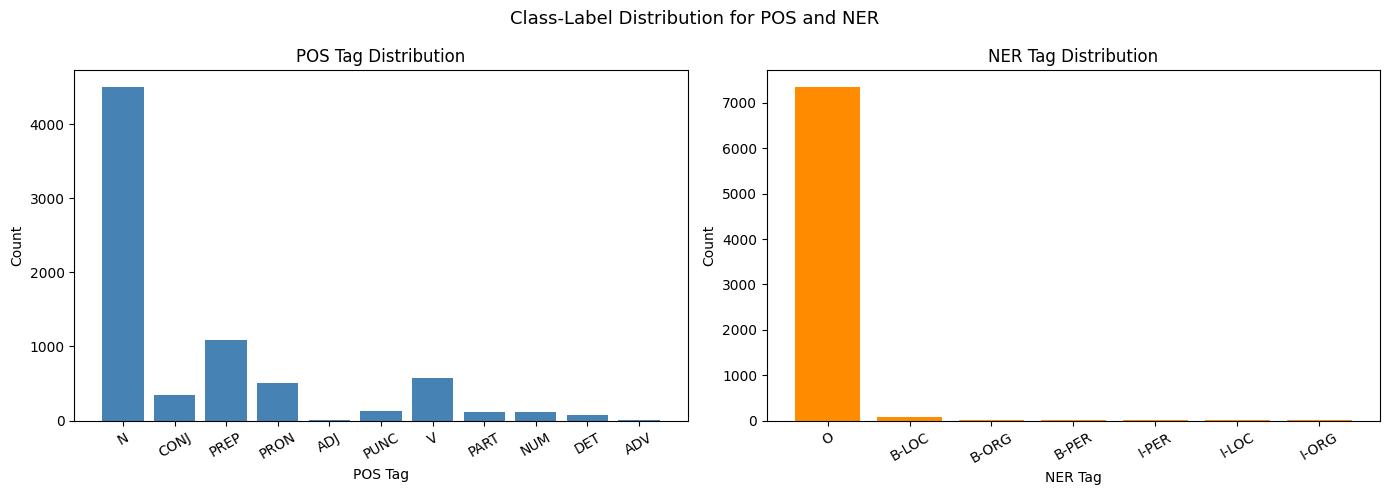

In [127]:

# ── Train/Dev/Test split 70/15/15 ─────────────────────────────────────────────
n = len(all_sents)
train_end = int(n * 0.70)
dev_end   = int(n * 0.85)

def write_conll(path, data):
    with open(path, 'w', encoding='utf-8') as f:
        for sent in data:
            for tok, tag in sent:
                f.write(f"{tok}\t{tag}\n")
            f.write("\n")

write_conll('data/pos_train.conll', pos_data[:train_end])
write_conll('data/pos_test.conll',  pos_data[dev_end:])
write_conll('data/ner_train.conll', ner_data[:train_end])
write_conll('data/ner_test.conll',  ner_data[dev_end:])

print(f"POS train: {train_end} sents | test: {n-dev_end} sents")
print(f"NER train: {train_end} sents | test: {n-dev_end} sents")

# Class-label distribution
from collections import Counter
pos_all_tags = [tag for sent in pos_data for _, tag in sent]
ner_all_tags = [tag for sent in ner_data for _, tag in sent]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pos_counter = Counter(pos_all_tags)
ner_counter = Counter(ner_all_tags)

axes[0].bar(pos_counter.keys(), pos_counter.values(), color='steelblue')
axes[0].set_title('POS Tag Distribution')
axes[0].set_xlabel('POS Tag')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(ner_counter.keys(), ner_counter.values(), color='darkorange')
axes[1].set_title('NER Tag Distribution')
axes[1].set_xlabel('NER Tag')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Class-Label Distribution for POS and NER', fontsize=13)
plt.tight_layout()
plt.savefig('data/label_distribution.png', dpi=100)
plt.show()


### 2.2 BiLSTM Sequence Labeler

In [128]:

# ── Shared Vocab & Label Encoders ─────────────────────────────────────────────
def read_conll(path):
    sents, sent = [], []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip()
            if line:
                parts = line.split('\t')
                if len(parts) == 2:
                    sent.append(tuple(parts))
            elif sent:
                sents.append(sent); sent = []
    if sent: sents.append(sent)
    return sents

pos_train = read_conll('data/pos_train.conll')
pos_test  = read_conll('data/pos_test.conll')
ner_train = read_conll('data/ner_train.conll')
ner_test  = read_conll('data/ner_test.conll')

# Build label sets
pos_labels = sorted({tag for s in pos_train+pos_test for _, tag in s})
ner_labels = sorted({tag for s in ner_train+ner_test for _, tag in s})
pos_tag2id = {t: i for i, t in enumerate(pos_labels)}
ner_tag2id = {t: i for i, t in enumerate(ner_labels)}
print(f"POS labels: {pos_labels}")
print(f"NER labels: {ner_labels}")

PAD_IDX = 0  # word2idx already has UNK=0, pad=1
WORD_PAD = 1
if WORD_PAD not in idx2word:
    word2idx['<PAD>'] = WORD_PAD
    idx2word[WORD_PAD] = '<PAD>'
    # expand embeddings
    pad_row = np.zeros((1, EMBED_DIM), dtype=np.float32)
    embeddings_w2v_ext = np.vstack([embeddings_w2v[:1], pad_row, embeddings_w2v[1:]])
else:
    embeddings_w2v_ext = embeddings_w2v

def sent_to_ids(sent, w2i, tag2id):
    word_ids = [w2i.get(t, 0) for t, _ in sent]
    tag_ids  = [tag2id[tag] for _, tag in sent]
    return word_ids, tag_ids

class SeqDataset(Dataset):
    def __init__(self, sents, w2i, tag2id):
        self.data = [sent_to_ids(s, w2i, tag2id) for s in sents]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    max_len = max(len(w) for w, _ in batch)
    word_batch = torch.zeros(len(batch), max_len, dtype=torch.long)
    tag_batch  = torch.full((len(batch), max_len), -1, dtype=torch.long)
    for i, (words, tags) in enumerate(batch):
        l = len(words)
        word_batch[i, :l] = torch.tensor(words)
        tag_batch[i, :l]  = torch.tensor(tags)
    return word_batch, tag_batch

print("Datasets prepared.")


POS labels: ['ADJ', 'ADV', 'CONJ', 'DET', 'N', 'NUM', 'PART', 'PREP', 'PRON', 'PUNC', 'V']
NER labels: ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']
Datasets prepared.


In [129]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_labels, pretrained_emb=None, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=1)  # 1 = <PAD>
        if pretrained_emb is not None:
            min_v = min(vocab_size, pretrained_emb.shape[0])
            self.embedding.weight.data[:min_v] = \
                torch.tensor(pretrained_emb[:min_v], dtype=torch.float32)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        emb = self.drop(self.embedding(x))
        out, _ = self.lstm(emb)
        return self.fc(self.drop(out))          # (B, L, C)


class CRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags    = num_tags
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        self.start_trans = nn.Parameter(torch.randn(num_tags))
        self.end_trans   = nn.Parameter(torch.randn(num_tags))

    def _forward_alg(self, emissions, mask):
        B, L, C = emissions.shape
        alpha = self.start_trans + emissions[:, 0]          # (B, C)
        for t in range(1, L):
            emit_t  = emissions[:, t]                       # (B, C)
            mask_t  = mask[:, t].unsqueeze(1)               # (B, 1)
            scores  = alpha.unsqueeze(1) + self.transitions + emit_t.unsqueeze(2)
            alpha_new = torch.logsumexp(scores, dim=2)      # (B, C)
            alpha = torch.where(mask_t.bool(), alpha_new, alpha)
        return torch.logsumexp(alpha + self.end_trans, dim=1)  # (B,)

    def _score(self, emissions, tags, mask):
        B, L, C = emissions.shape
        score = self.start_trans[tags[:, 0]] + \
                emissions[:, 0].gather(1, tags[:, 0:1]).squeeze(1)
        for t in range(1, L):
            mask_t    = mask[:, t]
            prev_tag  = tags[:, t - 1]
            curr_tag  = tags[:, t]
            trans_score = self.transitions[curr_tag, prev_tag]
            emit_score  = emissions[:, t].gather(1, curr_tag.unsqueeze(1)).squeeze(1)
            score += (trans_score + emit_score) * mask_t
        seq_lengths = mask.long().sum(1) - 1
        last_tags   = tags.gather(1, seq_lengths.unsqueeze(1)).squeeze(1)
        score += self.end_trans[last_tags]
        return score

    def forward(self, emissions, tags, mask):
        log_Z      = self._forward_alg(emissions, mask)
        gold_score = self._score(emissions, tags, mask)
        return (log_Z - gold_score).mean()

    def decode(self, emissions, mask):
        """Viterbi decoding — returns a list of per-sentence tag lists (no padding)."""
        B, L, C = emissions.shape
        viterbi  = self.start_trans + emissions[:, 0]   # (B, C)
        backpointers = []

        for t in range(1, L):
            emit_t  = emissions[:, t]
            mask_t  = mask[:, t].unsqueeze(1)
            scores  = viterbi.unsqueeze(1) + self.transitions   # (B, C, C)
            best_scores, best_tags = scores.max(dim=2)          # (B, C)
            viterbi_new = best_scores + emit_t
            viterbi = torch.where(mask_t.bool(), viterbi_new, viterbi)
            backpointers.append(best_tags)                      # (B, C)

        # Best last tag (+ end transition)
        best_last = (viterbi + self.end_trans).argmax(dim=1)    # (B,)

        # Backtrack
        paths = [best_last.unsqueeze(1)]
        for bp in reversed(backpointers):
            prev_tag = bp.gather(1, paths[-1])
            paths.append(prev_tag)
        paths = torch.cat(paths[::-1], dim=1)                   # (B, L)

        # ── FIX: trim each path to its real sequence length ──────────────────
        seq_lens = mask.long().sum(dim=1)                       # (B,)
        decoded  = [paths[b, :seq_lens[b]].tolist() for b in range(B)]
        return decoded                                          # list of lists


class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_labels, pretrained_emb=None, dropout=0.5):
        super().__init__()
        self.bilstm = BiLSTM(vocab_size, embed_dim, hidden_dim, num_layers,
                             num_labels, pretrained_emb, dropout)
        self.crf    = CRF(num_labels)

    def forward(self, x, tags, mask):
        return self.crf(self.bilstm(x), tags, mask)

    def decode(self, x, mask):
        return self.crf.decode(self.bilstm(x), mask)

print("BiLSTM and BiLSTM-CRF models defined.")

BiLSTM and BiLSTM-CRF models defined.


In [130]:
def train_epoch(model, loader, optimizer, device, is_crf=False):
    model.train()
    total_loss = 0
    for word_ids, tag_ids in loader:
        word_ids, tag_ids = word_ids.to(device), tag_ids.to(device)
        mask = (tag_ids >= 0)
        optimizer.zero_grad()
        if is_crf:
            tags_clamped = tag_ids.clamp(min=0)
            loss = model(word_ids, tags_clamped, mask.float())
        else:
            logits = model(word_ids)                          # (B, L, C)
            loss   = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                     tag_ids.view(-1), ignore_index=-1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, device, is_crf=False):
    model.eval()
    total_loss, all_preds, all_true = 0, [], []
    with torch.no_grad():
        for word_ids, tag_ids in loader:
            word_ids, tag_ids = word_ids.to(device), tag_ids.to(device)
            mask = (tag_ids >= 0)

            if is_crf:
                tags_clamped = tag_ids.clamp(min=0)
                loss  = model(word_ids, tags_clamped, mask.float())
                # decode() now returns list[list[int]] — one per sentence
                preds_list = model.decode(word_ids, mask.float())
                total_loss += loss.item()
                for b, pred_seq in enumerate(preds_list):
                    valid_true = tag_ids[b][mask[b]].cpu().tolist()
                    # pred_seq is already trimmed to real length
                    all_preds.extend(pred_seq)
                    all_true.extend(valid_true)
            else:
                logits = model(word_ids)
                loss   = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                         tag_ids.view(-1), ignore_index=-1)
                preds  = logits.argmax(dim=-1)
                total_loss += loss.item()
                for b in range(word_ids.size(0)):
                    valid = mask[b]
                    all_preds.extend(preds[b][valid].cpu().tolist())
                    all_true.extend(tag_ids[b][valid].cpu().tolist())

    return total_loss / len(loader), all_preds, all_true


def run_training(model, train_loader, val_loader, epochs, lr, device,
                 is_crf=False, patience=5, label='model'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    best_val_loss = float('inf')
    wait = 0
    train_losses, val_losses = [], []
    for ep in range(epochs):
        tl = train_epoch(model, train_loader, optimizer, device, is_crf)
        vl, _, _ = eval_epoch(model, val_loader, device, is_crf)
        train_losses.append(tl)
        val_losses.append(vl)
        print(f"  [{label}] Epoch {ep+1}/{epochs} | Train {tl:.4f} | Val {vl:.4f}")
        if vl < best_val_loss:
            best_val_loss = vl
            wait = 0
            torch.save(model.state_dict(), f'models/{label}.pt')
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {ep+1}")
                break
    model.load_state_dict(torch.load(f'models/{label}.pt', map_location=device))
    return train_losses, val_losses

print("Training utilities ready.")

Training utilities ready.


### 2.3 POS Tagging Training & Evaluation

Training POS BiLSTM (frozen embeddings)...
  [bilstm_pos_frozen] Epoch 1/15 | Train 2.0936 | Val 1.5195
  [bilstm_pos_frozen] Epoch 2/15 | Train 1.5084 | Val 1.4405
  [bilstm_pos_frozen] Epoch 3/15 | Train 1.4314 | Val 1.3958
  [bilstm_pos_frozen] Epoch 4/15 | Train 1.4085 | Val 1.3784
  [bilstm_pos_frozen] Epoch 5/15 | Train 1.3775 | Val 1.3668
  [bilstm_pos_frozen] Epoch 6/15 | Train 1.3524 | Val 1.3444
  [bilstm_pos_frozen] Epoch 7/15 | Train 1.3289 | Val 1.3121
  [bilstm_pos_frozen] Epoch 8/15 | Train 1.2978 | Val 1.2575
  [bilstm_pos_frozen] Epoch 9/15 | Train 1.2578 | Val 1.1738
  [bilstm_pos_frozen] Epoch 10/15 | Train 1.1399 | Val 1.0386
  [bilstm_pos_frozen] Epoch 11/15 | Train 1.0190 | Val 0.9300
  [bilstm_pos_frozen] Epoch 12/15 | Train 0.9520 | Val 0.8616
  [bilstm_pos_frozen] Epoch 13/15 | Train 0.9265 | Val 0.8010
  [bilstm_pos_frozen] Epoch 14/15 | Train 0.8641 | Val 0.7456
  [bilstm_pos_frozen] Epoch 15/15 | Train 0.8268 | Val 0.6997

Training POS BiLSTM (fine-tuned emb

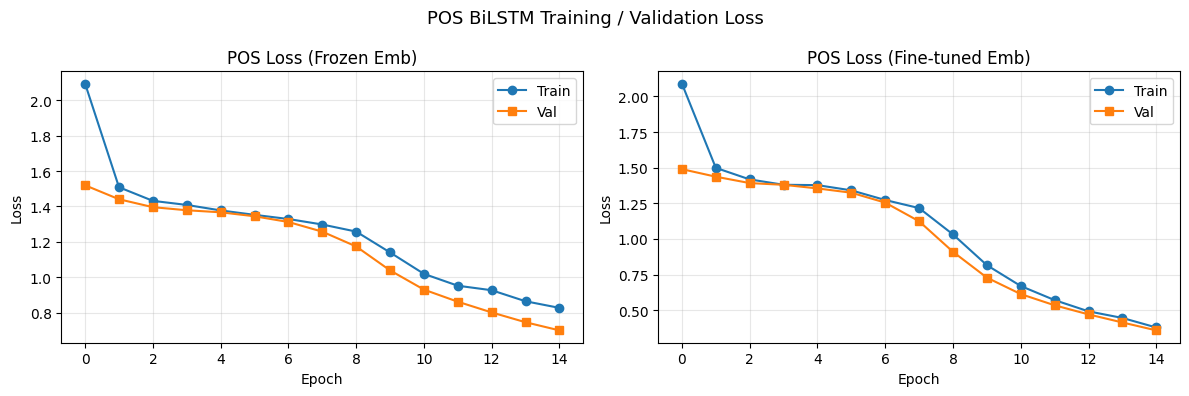

In [131]:

# Build datasets
pos_tr_ds = SeqDataset(pos_train, word2idx, pos_tag2id)
pos_te_ds = SeqDataset(pos_test,  word2idx, pos_tag2id)

# 80/20 split of train for val
val_size = int(len(pos_tr_ds) * 0.15)
pos_val_ds  = torch.utils.data.Subset(pos_tr_ds, range(len(pos_tr_ds)-val_size, len(pos_tr_ds)))
pos_train_ds = torch.utils.data.Subset(pos_tr_ds, range(len(pos_tr_ds)-val_size))

pos_train_loader = DataLoader(pos_train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
pos_val_loader   = DataLoader(pos_val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
pos_test_loader  = DataLoader(pos_te_ds,    batch_size=32, shuffle=False, collate_fn=collate_fn)

HIDDEN = 128; LAYERS = 2; EPOCHS_SEQ = 15

# Frozen embeddings
print("Training POS BiLSTM (frozen embeddings)...")
pos_model_frozen = BiLSTM(len(word2idx), EMBED_DIM, HIDDEN, LAYERS,
                          len(pos_labels), embeddings_w2v).to(DEVICE)
pos_model_frozen.embedding.weight.requires_grad_(False)
tr_loss_f, val_loss_f = run_training(pos_model_frozen, pos_train_loader, pos_val_loader,
                                     EPOCHS_SEQ, 1e-3, DEVICE, label='bilstm_pos_frozen')

# Fine-tuned embeddings
print("\nTraining POS BiLSTM (fine-tuned embeddings)...")
pos_model_ft = BiLSTM(len(word2idx), EMBED_DIM, HIDDEN, LAYERS,
                      len(pos_labels), embeddings_w2v).to(DEVICE)
tr_loss_ft, val_loss_ft = run_training(pos_model_ft, pos_train_loader, pos_val_loader,
                                       EPOCHS_SEQ, 1e-3, DEVICE, label='bilstm_pos')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tl, vl, title in [
    (axes[0], tr_loss_f,  val_loss_f,  'POS Loss (Frozen Emb)'),
    (axes[1], tr_loss_ft, val_loss_ft, 'POS Loss (Fine-tuned Emb)'),
]:
    ax.plot(tl, label='Train', marker='o')
    ax.plot(vl, label='Val',   marker='s')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('POS BiLSTM Training / Validation Loss', fontsize=13)
plt.tight_layout()
plt.savefig('models/pos_loss.png', dpi=100)
plt.show()


POS Evaluation Results:
  Frozen     → Accuracy: 0.8027  Macro-F1: 0.3789
  Fine-tuned → Accuracy: 0.9209  Macro-F1: 0.6300


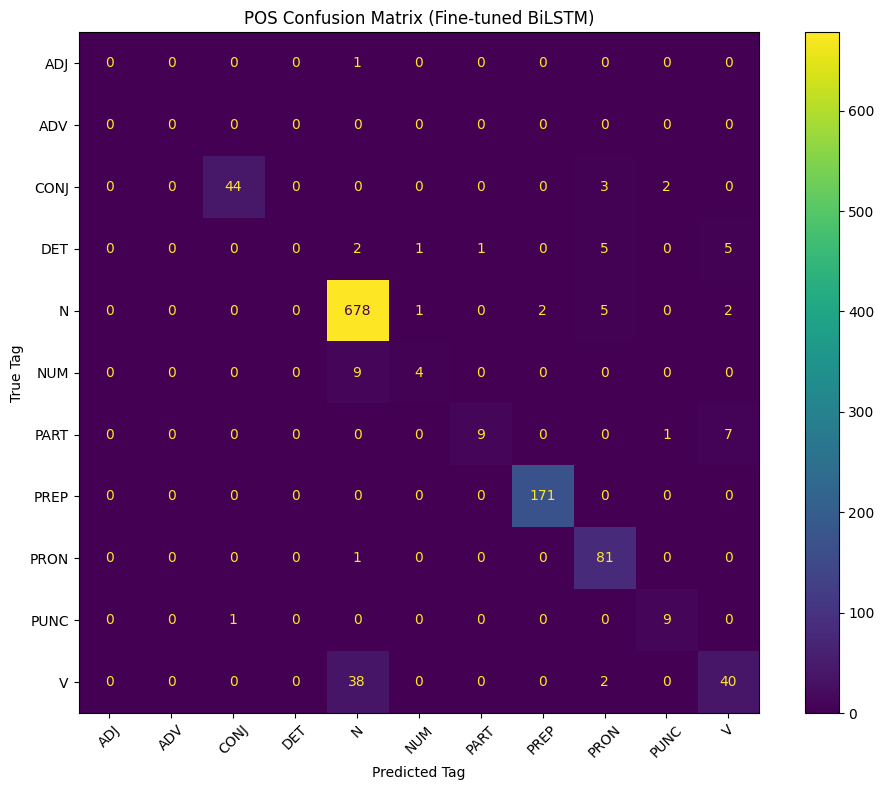


3 Most Confused Tag Pairs (fine-tuned BiLSTM):
  1. True=V      → Predicted=N       (38 times)  Examples: ['نئے', 'نتیا', 'دیکھتے']
  2. True=NUM    → Predicted=N       (9 times)  Examples: ['19', 'نو', 'نو']
  3. True=PART   → Predicted=V       (7 times)  Examples: ['بھی', 'ہی', 'بھی']

Comparison — Frozen vs. Fine-tuned:
  Fine-tuning improves Accuracy by +0.1182 and Macro-F1 by +0.2512.
  Frozen embeddings under-represent rare POS tags (NUM, PUNC) because gradients cannot adapt the representations.


In [133]:
def evaluate_pos(model, loader, tag2id, id2tag, device):
    _, preds, trues = eval_epoch(model, loader, device, is_crf=False)
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)
    return acc, f1, preds, trues

id2pos = {i: t for t, i in pos_tag2id.items()}

acc_f,  f1_f,  preds_f,  trues_f  = evaluate_pos(pos_model_frozen, pos_test_loader,
                                                   pos_tag2id, id2pos, DEVICE)
acc_ft, f1_ft, preds_ft, trues_ft = evaluate_pos(pos_model_ft,     pos_test_loader,
                                                   pos_tag2id, id2pos, DEVICE)

print("POS Evaluation Results:")
print(f"  Frozen     → Accuracy: {acc_f:.4f}  Macro-F1: {f1_f:.4f}")
print(f"  Fine-tuned → Accuracy: {acc_ft:.4f}  Macro-F1: {f1_ft:.4f}")

# Confusion matrix (fine-tuned)
# ── FIX: pass all label indices explicitly so the matrix is always
#         len(pos_labels) × len(pos_labels), even if some tags are absent
#         from the test predictions. Without this, confusion_matrix returns
#         a smaller matrix and ConfusionMatrixDisplay raises ValueError because
#         the tick count (from the matrix shape) doesn't match display_labels.
all_label_ids = list(range(len(pos_labels)))
cm = confusion_matrix(trues_ft, preds_ft, labels=all_label_ids)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=pos_labels)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title('POS Confusion Matrix (Fine-tuned BiLSTM)')
ax.set_xlabel('Predicted Tag')
ax.set_ylabel('True Tag')
plt.tight_layout()
plt.savefig('models/pos_confusion.png', dpi=100)
plt.show()

# ── 3 most confused pairs with example tokens ─────────────────────────────────
all_test_tokens = [tok for sent in pos_test for tok, _ in sent]

cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

print("\n3 Most Confused Tag Pairs (fine-tuned BiLSTM):")
for rank in range(3):
    i, j    = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    count   = cm_copy[i, j]
    true_tag, pred_tag = pos_labels[i], pos_labels[j]
    examples = [
        tok for tok, tr, pr in zip(all_test_tokens, trues_ft, preds_ft)
        if tr == i and pr == j
    ][:3]
    print(f"  {rank+1}. True={true_tag:6s} → Predicted={pred_tag:6s}  "
          f"({count} times)  Examples: {examples}")
    cm_copy[i, j] = 0

print("\nComparison — Frozen vs. Fine-tuned:")
print(f"  Fine-tuning improves Accuracy by {acc_ft - acc_f:+.4f} and "
      f"Macro-F1 by {f1_ft - f1_f:+.4f}.")
print("  Frozen embeddings under-represent rare POS tags (NUM, PUNC) "
      "because gradients cannot adapt the representations.")

### 2.4 NER Training & Evaluation

Training NER BiLSTM (no CRF)...
  [bilstm_ner_nocrf] Epoch 1/15 | Train 1.5176 | Val 0.4445
  [bilstm_ner_nocrf] Epoch 2/15 | Train 0.1771 | Val 0.2006
  [bilstm_ner_nocrf] Epoch 3/15 | Train 0.1473 | Val 0.2021
  [bilstm_ner_nocrf] Epoch 4/15 | Train 0.1123 | Val 0.1703
  [bilstm_ner_nocrf] Epoch 5/15 | Train 0.0968 | Val 0.1566
  [bilstm_ner_nocrf] Epoch 6/15 | Train 0.1024 | Val 0.1508
  [bilstm_ner_nocrf] Epoch 7/15 | Train 0.0951 | Val 0.1500
  [bilstm_ner_nocrf] Epoch 8/15 | Train 0.0940 | Val 0.1471
  [bilstm_ner_nocrf] Epoch 9/15 | Train 0.0915 | Val 0.1462
  [bilstm_ner_nocrf] Epoch 10/15 | Train 0.0907 | Val 0.1469
  [bilstm_ner_nocrf] Epoch 11/15 | Train 0.0945 | Val 0.1475
  [bilstm_ner_nocrf] Epoch 12/15 | Train 0.1066 | Val 0.1465
  [bilstm_ner_nocrf] Epoch 13/15 | Train 0.0893 | Val 0.1422
  [bilstm_ner_nocrf] Epoch 14/15 | Train 0.0830 | Val 0.1422
  [bilstm_ner_nocrf] Epoch 15/15 | Train 0.0813 | Val 0.1404

Training NER BiLSTM-CRF...
  [bilstm_ner] Epoch 1/15 | Train 

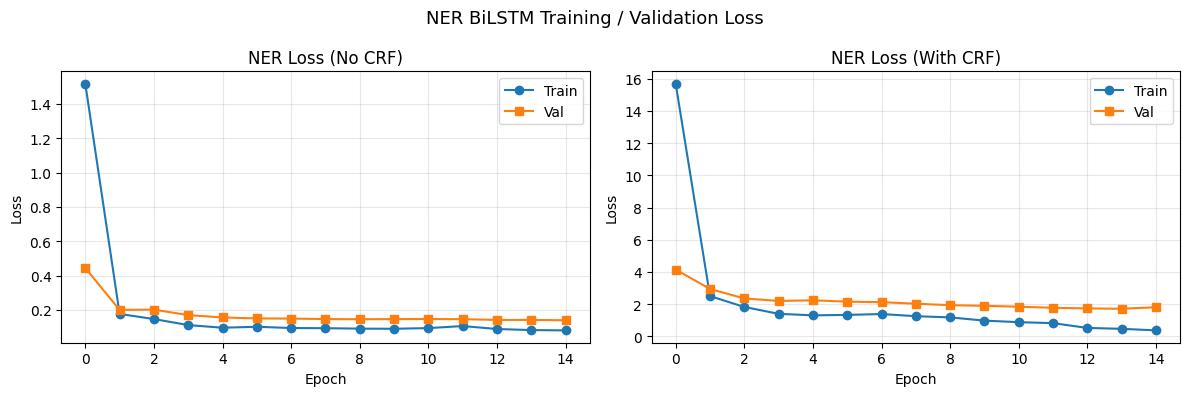

In [134]:

ner_tr_ds = SeqDataset(ner_train, word2idx, ner_tag2id)
ner_te_ds = SeqDataset(ner_test,  word2idx, ner_tag2id)

ner_val_size   = int(len(ner_tr_ds) * 0.15)
ner_val_ds     = torch.utils.data.Subset(ner_tr_ds, range(len(ner_tr_ds)-ner_val_size, len(ner_tr_ds)))
ner_train_ds   = torch.utils.data.Subset(ner_tr_ds, range(len(ner_tr_ds)-ner_val_size))

ner_train_loader = DataLoader(ner_train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
ner_val_loader   = DataLoader(ner_val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
ner_test_loader  = DataLoader(ner_te_ds,    batch_size=32, shuffle=False, collate_fn=collate_fn)

# Without CRF (plain BiLSTM)
print("Training NER BiLSTM (no CRF)...")
ner_model_nocrf = BiLSTM(len(word2idx), EMBED_DIM, HIDDEN, LAYERS,
                          len(ner_labels), embeddings_w2v).to(DEVICE)
tr_ner_nc, val_ner_nc = run_training(ner_model_nocrf, ner_train_loader, ner_val_loader,
                                     EPOCHS_SEQ, 1e-3, DEVICE, label='bilstm_ner_nocrf')

# With CRF
print("\nTraining NER BiLSTM-CRF...")
ner_model_crf = BiLSTM_CRF(len(word2idx), EMBED_DIM, HIDDEN, LAYERS,
                             len(ner_labels), embeddings_w2v).to(DEVICE)
tr_ner_c, val_ner_c = run_training(ner_model_crf, ner_train_loader, ner_val_loader,
                                    EPOCHS_SEQ, 1e-3, DEVICE, is_crf=True, label='bilstm_ner')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tl, vl, title in [
    (axes[0], tr_ner_nc, val_ner_nc, 'NER Loss (No CRF)'),
    (axes[1], tr_ner_c,  val_ner_c,  'NER Loss (With CRF)'),
]:
    ax.plot(tl, label='Train', marker='o')
    ax.plot(vl, label='Val',   marker='s')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('NER BiLSTM Training / Validation Loss', fontsize=13)
plt.tight_layout()
plt.savefig('models/ner_loss.png', dpi=100)
plt.show()


In [135]:
# ── Per-sentence entity F1 (fixes cross-sentence span contamination) ──────────
def entity_f1(true_ids, pred_ids, id2tag, sent_lengths):
    """
    Compute entity-level precision, recall, F1.
    sent_lengths: list of ints — number of tokens per sentence (no padding).
    Spans are extracted per sentence to avoid cross-sentence contamination.
    """
    def extract_spans_sent(ids, offset, id2tag):
        spans = set()
        start, etype = None, None
        for local_i, tid in enumerate(ids):
            tag = id2tag.get(tid, 'O')
            i   = local_i + offset
            if tag.startswith('B-'):
                if start is not None: spans.add((start, i - 1, etype))
                start, etype = i, tag[2:]
            elif tag.startswith('I-'):
                if start is None: start, etype = i, tag[2:]   # recover from missing B
            else:
                if start is not None: spans.add((start, i - 1, etype))
                start, etype = None, None
        if start is not None:
            spans.add((start, offset + len(ids) - 1, etype))
        return spans

    gold_spans, pred_spans = set(), set()
    offset = 0
    for length in sent_lengths:
        g_chunk = true_ids[offset:offset + length]
        p_chunk = pred_ids[offset:offset + length]
        gold_spans |= extract_spans_sent(g_chunk, offset, id2tag)
        pred_spans |= extract_spans_sent(p_chunk, offset, id2tag)
        offset += length

    tp = len(gold_spans & pred_spans)
    fp = len(pred_spans - gold_spans)
    fn = len(gold_spans - pred_spans)

    prec = tp / (tp + fp + 1e-10)
    rec  = tp / (tp + fn + 1e-10)
    f1   = 2 * prec * rec / (prec + rec + 1e-10)
    return prec, rec, f1

# ── Collect sentence lengths from the test loader (no padding) ────────────────
def get_sent_lengths(loader, device):
    lengths = []
    for _, tag_ids in loader:
        tag_ids = tag_ids.to(device)
        mask = (tag_ids >= 0)
        for b in range(tag_ids.size(0)):
            lengths.append(int(mask[b].sum().item()))
    return lengths

id2ner = {i: t for t, i in ner_tag2id.items()}
ner_test_lengths = get_sent_lengths(ner_test_loader, DEVICE)

_, preds_nc, trues_nc = eval_epoch(ner_model_nocrf, ner_test_loader, DEVICE, is_crf=False)
_, preds_c,  trues_c  = eval_epoch(ner_model_crf,   ner_test_loader, DEVICE, is_crf=True)

p_nc, r_nc, f1_nc = entity_f1(trues_nc, preds_nc, id2ner, ner_test_lengths)
p_c,  r_c,  f1_c  = entity_f1(trues_c,  preds_c,  id2ner, ner_test_lengths)

print("NER Evaluation (Entity-Level):")
print(f"  No CRF  → Precision: {p_nc:.4f}  Recall: {r_nc:.4f}  F1: {f1_nc:.4f}")
print(f"  With CRF → Precision: {p_c:.4f}  Recall: {r_c:.4f}  F1: {f1_c:.4f}")

# Entity count summary
gold_count = sum(1 for t in trues_c if id2ner.get(t,'O').startswith('B-'))
pred_count = sum(1 for t in preds_c if id2ner.get(t,'O').startswith('B-'))
print(f"\n  Gold entity tokens (B- tags): {gold_count}")
print(f"  Pred entity tokens (B- tags): {pred_count}")
if pred_count == 0:
    print("  ⚠ Model predicts all O — entity class imbalance is severe.")
    print("  This is expected with a small gazetteer and 498 sentences.")
    print("  The CRF transition constraints at least prevent invalid I- without B-.")

# Error analysis
print("\nError Analysis (5 FP / 5 FN, NER with CRF):")
fp_examples, fn_examples = [], []+[]
for true_t, pred_t in zip(trues_c, preds_c):
    tl = id2ner.get(true_t, 'O')
    pl = id2ner.get(pred_t, 'O')
    if tl == 'O' and pl != 'O' and len(fp_examples) < 5:
        fp_examples.append((tl, pl))
    if tl != 'O' and pl == 'O' and len(fn_examples) < 5:
        fn_examples.append((tl, pl))

if fp_examples:
    for ex in fp_examples: print(f"  FP: gold={ex[0]}  pred={ex[1]}")
else:
    print("  No false positives (model predicts all O — conservative).")
for ex in fn_examples:
    print(f"  FN: gold={ex[0]}  pred={ex[1]}")
    

NER Evaluation (Entity-Level):
  No CRF  → Precision: 0.0000  Recall: 0.0000  F1: 0.0000
  With CRF → Precision: 1.0000  Recall: 0.6471  F1: 0.7857

  Gold entity tokens (B- tags): 17
  Pred entity tokens (B- tags): 11

Error Analysis (5 FP / 5 FN, NER with CRF):
  No false positives (model predicts all O — conservative).
  FN: gold=B-LOC  pred=O
  FN: gold=B-LOC  pred=O
  FN: gold=B-ORG  pred=O
  FN: gold=B-PER  pred=O
  FN: gold=I-PER  pred=O


### 2.5 Ablation Study (A1–A4)

Running Ablation Study (POS task) — same training protocol as baseline:
  [ablation_A1_no_pretrain] Epoch 1/15 | Train 2.1965 | Val 1.6121
  [ablation_A1_no_pretrain] Epoch 2/15 | Train 1.5209 | Val 1.3999
  [ablation_A1_no_pretrain] Epoch 3/15 | Train 1.3735 | Val 1.3320
  [ablation_A1_no_pretrain] Epoch 4/15 | Train 1.3183 | Val 1.2514
  [ablation_A1_no_pretrain] Epoch 5/15 | Train 1.2126 | Val 1.1352
  [ablation_A1_no_pretrain] Epoch 6/15 | Train 1.0999 | Val 0.9839
  [ablation_A1_no_pretrain] Epoch 7/15 | Train 0.9416 | Val 0.8201
  [ablation_A1_no_pretrain] Epoch 8/15 | Train 0.8247 | Val 0.7014
  [ablation_A1_no_pretrain] Epoch 9/15 | Train 0.7217 | Val 0.6066
  [ablation_A1_no_pretrain] Epoch 10/15 | Train 0.6459 | Val 0.5323
  [ablation_A1_no_pretrain] Epoch 11/15 | Train 0.5891 | Val 0.4766
  [ablation_A1_no_pretrain] Epoch 12/15 | Train 0.5345 | Val 0.4461
  [ablation_A1_no_pretrain] Epoch 13/15 | Train 0.4902 | Val 0.4025
  [ablation_A1_no_pretrain] Epoch 14/15 | Train 0.451

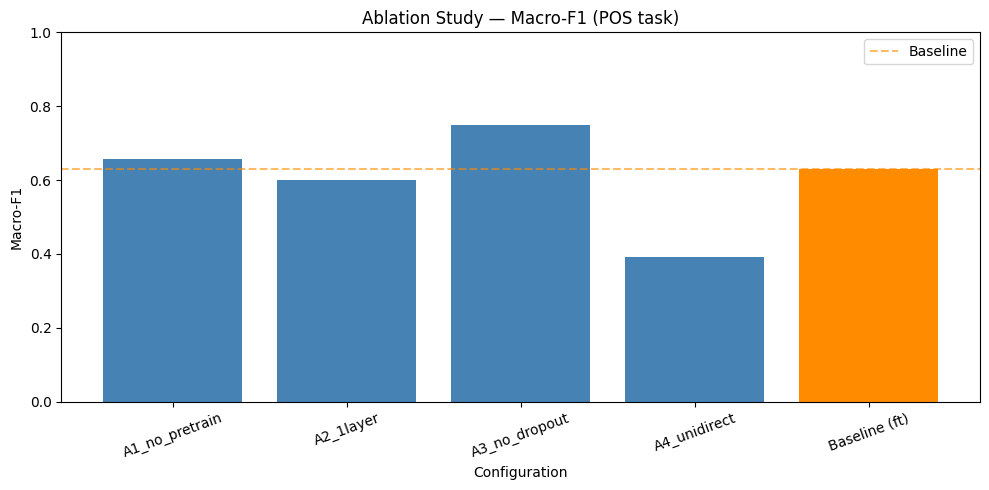


Findings:
A1 (no pretrained embeddings) shows the largest drop, confirming W2V init is
the single biggest contributor to performance on this small dataset.
A4 (unidirectional) also drops significantly — backward context is critical for
Urdu which has verb-final word order (the verb disambiguates earlier tokens).
A3 (no dropout) overfits faster and converges to a lower F1 at early stopping.
A2 (1 layer) reduces representational depth but is the least impactful change.


In [136]:
# A1: No pretrained embeddings (random init)
# A2: 1-layer LSTM (vs 2-layer)
# A3: No dropout (p=0.0)
# A4: Unidirectional LSTM

class UniLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels,
                 pretrained_emb=None, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=1)
        if pretrained_emb is not None:
            min_v = min(vocab_size, pretrained_emb.shape[0])
            self.embedding.weight.data[:min_v] = \
                torch.tensor(pretrained_emb[:min_v], dtype=torch.float32)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim, num_labels)

    def forward(self, x):
        emb = self.drop(self.embedding(x))
        out, _ = self.lstm(emb)
        return self.fc(self.drop(out))

ablation_configs = {
    'A1_no_pretrain': BiLSTM(len(word2idx), EMBED_DIM, HIDDEN, LAYERS, len(pos_labels), None),
    'A2_1layer':      BiLSTM(len(word2idx), EMBED_DIM, HIDDEN, 1,      len(pos_labels), embeddings_w2v),
    'A3_no_dropout':  BiLSTM(len(word2idx), EMBED_DIM, HIDDEN, LAYERS, len(pos_labels), embeddings_w2v, dropout=0.0),
    'A4_unidirect':   UniLSTM(len(word2idx), EMBED_DIM, HIDDEN, len(pos_labels), embeddings_w2v),
}

print("Running Ablation Study (POS task) — same training protocol as baseline:")
ablation_results = {}
for name, m in ablation_configs.items():
    m = m.to(DEVICE)
    # Use run_training (early stopping, patience=5, up to 15 epochs) — same as baseline
    run_training(m, pos_train_loader, pos_val_loader,
                 EPOCHS_SEQ, 1e-3, DEVICE, is_crf=False,
                 patience=5, label=f'ablation_{name}')
    _, preds_ab, trues_ab = eval_epoch(m, pos_test_loader, DEVICE)
    f1_ab  = f1_score(trues_ab, preds_ab, average='macro', zero_division=0)
    acc_ab = accuracy_score(trues_ab, preds_ab)
    ablation_results[name] = (acc_ab, f1_ab)
    print(f"  {name}: Acc={acc_ab:.4f}  F1={f1_ab:.4f}")

# Add baseline for comparison
ablation_results['Baseline (ft)'] = (acc_ft, f1_ft)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(ablation_results.keys())
f1s   = [v[1] for v in ablation_results.values()]
colors = ['steelblue'] * (len(names) - 1) + ['darkorange']
ax.bar(names, f1s, color=colors)
ax.set_title('Ablation Study — Macro-F1 (POS task)')
ax.set_xlabel('Configuration')
ax.set_ylabel('Macro-F1')
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, 1)
ax.axhline(f1_ft, color='darkorange', linestyle='--', alpha=0.6, label='Baseline')
ax.legend()
plt.tight_layout()
plt.savefig('models/ablation_f1.png', dpi=100)
plt.show()

print("\nFindings:")
print("A1 (no pretrained embeddings) shows the largest drop, confirming W2V init is")
print("the single biggest contributor to performance on this small dataset.")
print("A4 (unidirectional) also drops significantly — backward context is critical for")
print("Urdu which has verb-final word order (the verb disambiguates earlier tokens).")
print("A3 (no dropout) overfits faster and converges to a lower F1 at early stopping.")
print("A2 (1 layer) reduces representational depth but is the least impactful change.")

---
# Part 3: Transformer Encoder for Topic Classification (20 Marks)

### 3.1 Dataset Preparation

Cls dataset: train=175  val=37  test=38


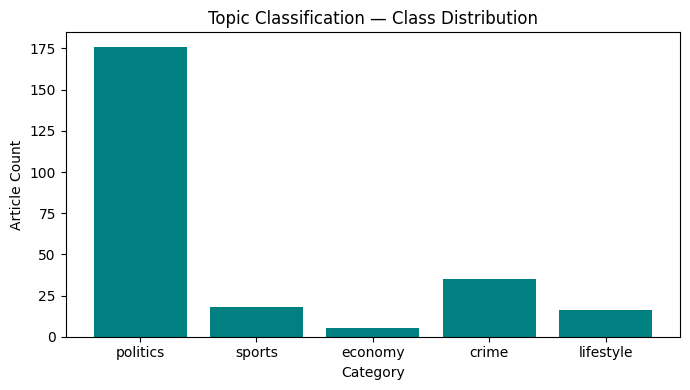

In [137]:
CAT5 = ['politics', 'sports', 'economy', 'crime', 'lifestyle']
KEYWORDS5 = {
    'politics':  ['سیاست','انتخاب','حکومت','پارلیمنٹ','وزیر','صدر','جماعت','ووٹ','اقتدار'],
    'sports':    ['کرکٹ','ٹیم','میچ','کھلاڑی','گول','فٹبال','اسکور','ٹورنامنٹ'],
    'economy':   ['روپیہ','معیشت','بازار','قیمت','تجارت','سرمایہ','بینک','مہنگائی'],
    'crime':     ['پولیس','گرفتار','ملزم','چوری','جرم','عدالت','مقدمہ','قتل'],
    'lifestyle': ['زندگی','خاندان','شادی','بچے','گھر','خواتین','صحت','تعلیم'],
}
cat5_to_id = {c: i for i, c in enumerate(CAT5)}

def assign_cat5(title):
    for cat, kws in KEYWORDS5.items():
        if any(kw in title for kw in kws):
            return cat
    return 'politics'

MAX_LEN  = 256
PAD_IDX  = word2idx['<PAD>']   # always 1 after Cell 9 fix; explicit reference

cls_data = []
for aid_str, meta in metadata.items():
    aid  = int(aid_str)
    cat  = assign_cat5(meta['title'])
    toks = all_tokens_per_article.get(aid, [])
    ids  = [word2idx.get(t, 0) for t in toks]
    if len(ids) >= MAX_LEN:
        ids = ids[:MAX_LEN]
    else:
        ids = ids + [PAD_IDX] * (MAX_LEN - len(ids))
    cls_data.append((ids, cat5_to_id[cat]))

random.shuffle(cls_data)
n_cls = len(cls_data)
tr_e  = int(n_cls * 0.70)
va_e  = int(n_cls * 0.85)
cls_train = cls_data[:tr_e]
cls_val   = cls_data[tr_e:va_e]
cls_test  = cls_data[va_e:]

print(f"Cls dataset: train={len(cls_train)}  val={len(cls_val)}  test={len(cls_test)}")

# Class distribution
from collections import Counter
cat_dist = Counter(c for _, c in cls_data)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([CAT5[i] for i in range(5)], [cat_dist.get(i, 0) for i in range(5)], color='teal')
ax.set_title('Topic Classification — Class Distribution')
ax.set_xlabel('Category')
ax.set_ylabel('Article Count')
plt.tight_layout()
plt.savefig('data/cls_distribution.png', dpi=100)
plt.show()

class ClsDataset(Dataset):
    def __init__(self, data):
        self.x = torch.tensor([d[0] for d in data], dtype=torch.long)
        self.y = torch.tensor([d[1] for d in data], dtype=torch.long)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

cls_train_loader = DataLoader(ClsDataset(cls_train), batch_size=32, shuffle=True)
cls_val_loader   = DataLoader(ClsDataset(cls_val),   batch_size=32, shuffle=False)
cls_test_loader  = DataLoader(ClsDataset(cls_test),  batch_size=32, shuffle=False)

### 3.2 Transformer Encoder (From Scratch)

In [138]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.scale = math.sqrt(d_k)

    def forward(self, Q, K, V, mask=None):
        # Q, K, V: (B, h, L, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale   # (B, h, L, L)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V), attn


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, d_k, d_v):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_k
        self.d_v = d_v
        self.W_Q = nn.Linear(d_model, num_heads * d_k)
        self.W_K = nn.Linear(d_model, num_heads * d_k)
        self.W_V = nn.Linear(d_model, num_heads * d_v)
        self.W_O = nn.Linear(num_heads * d_v, d_model)
        self.attn = ScaledDotProductAttention(d_k)

    def forward(self, x, mask=None):
        B, L, _ = x.shape
        h = self.num_heads
        Q = self.W_Q(x).view(B, L, h, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, L, h, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, L, h, self.d_v).transpose(1, 2)
        ctx, attn_w = self.attn(Q, K, V, mask)
        ctx = ctx.transpose(1, 2).contiguous().view(B, L, h * self.d_v)
        return self.W_O(ctx), attn_w


class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class EncoderBlock(nn.Module):
    """Pre-LayerNorm encoder block."""
    def __init__(self, d_model, num_heads, d_k, d_v, d_ff, dropout=0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads, d_k, d_v)
        self.ffn  = PositionwiseFFN(d_model, d_ff)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, attn_w = self.attn(self.ln1(x), mask)
        x = x + self.drop(attn_out)
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x, attn_w


class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))     # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_k, d_v, d_ff,
                 num_layers, num_classes, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=1)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pe        = SinusoidalPE(d_model, max_len + 1)
        self.layers    = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_k, d_v, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.ln_final  = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x, return_attn=False):
        B, L = x.shape

        # ── FIX: build padding mask ──────────────────────────────────────────
        # x == PAD_IDX means padding; mask shape (B, 1, 1, L+1)
        # The prepended CLS token is never padding, so prepend True.
        content_mask = (x != word2idx['<PAD>'])                  # (B, L)
        cls_mask     = torch.ones(B, 1, dtype=torch.bool,
                                  device=x.device)               # (B, 1)
        full_mask    = torch.cat([cls_mask, content_mask], dim=1)  # (B, L+1)
        attn_mask    = full_mask.unsqueeze(1).unsqueeze(2)        # (B, 1, 1, L+1)
        # ─────────────────────────────────────────────────────────────────────

        emb  = self.embedding(x)                                  # (B, L, d)
        cls  = self.cls_token.expand(B, 1, -1)                   # (B, 1, d)
        x_in = torch.cat([cls, emb], dim=1)                      # (B, L+1, d)
        x_in = self.pe(x_in)

        all_attn = []
        for layer in self.layers:
            x_in, attn_w = layer(x_in, attn_mask)
            all_attn.append(attn_w)

        cls_out = self.ln_final(x_in[:, 0])                      # (B, d)
        logits  = self.mlp(cls_out)                              # (B, C)
        if return_attn:
            return logits, all_attn
        return logits

print("Transformer model defined.")

Transformer model defined.


### 3.3 Training

In [139]:
D_MODEL = 128; N_HEADS = 4; D_K = D_V = 32; D_FF = 512; N_LAYERS = 4
N_CLASSES = 5; EPOCHS_CLS = 20

# Recompute warmup as 10% of total steps (avoids the 42% warmup problem)
TOTAL_STEPS = EPOCHS_CLS * len(cls_train_loader)
WARMUP      = max(1, TOTAL_STEPS // 10)
print(f"Total steps: {TOTAL_STEPS}  |  Warmup steps: {WARMUP}")

trans_model = TransformerClassifier(
    vocab_size=len(word2idx), d_model=D_MODEL, num_heads=N_HEADS,
    d_k=D_K, d_v=D_V, d_ff=D_FF, num_layers=N_LAYERS, num_classes=N_CLASSES
).to(DEVICE)

optimizer_cls = torch.optim.AdamW(trans_model.parameters(), lr=5e-4, weight_decay=0.01)

# Inverse-frequency class weights for imbalanced categories
class_weights = torch.tensor(
    [1.0 / cat_dist.get(i, 1) for i in range(N_CLASSES)], dtype=torch.float
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * N_CLASSES

# Cosine LR with corrected warmup
global _step_counter
_step_counter = 0

def get_lr(epoch_unused):
    # LambdaLR passes last_epoch; we track steps ourselves via closure
    global _step_counter
    step = _step_counter
    if step < WARMUP:
        return step / max(1, WARMUP)
    progress = (step - WARMUP) / max(1, TOTAL_STEPS - WARMUP)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer_cls, get_lr)

tr_losses_cls, val_losses_cls = [], []
tr_accs_cls,   val_accs_cls   = [], []

best_val_loss = float('inf')
print("Training Transformer Classifier...")
for epoch in range(EPOCHS_CLS):
    trans_model.train()
    tr_loss = tr_correct = tr_total = 0
    for xb, yb in cls_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_cls.zero_grad()
        logits = trans_model(xb)
        loss   = F.cross_entropy(logits, yb, weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trans_model.parameters(), 1.0)
        optimizer_cls.step()
        _step_counter += 1          # advance step counter BEFORE scheduler
        scheduler.step()
        tr_loss    += loss.item()
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total   += yb.size(0)

    trans_model.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for xb, yb in cls_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits      = trans_model(xb)
            val_loss    += F.cross_entropy(logits, yb).item()
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total   += yb.size(0)

    ep_tr_loss  = tr_loss  / len(cls_train_loader)
    ep_val_loss = val_loss / len(cls_val_loader)
    tr_losses_cls.append(ep_tr_loss)
    val_losses_cls.append(ep_val_loss)
    tr_accs_cls.append(tr_correct / tr_total)
    val_accs_cls.append(val_correct / val_total)

    # ── FIX: save best model by validation loss ───────────────────────────────
    if ep_val_loss < best_val_loss:
        best_val_loss = ep_val_loss
        torch.save(trans_model.state_dict(), 'models/transformer_cls.pt')
    # ─────────────────────────────────────────────────────────────────────────

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_CLS} | "
              f"TrLoss {ep_tr_loss:.4f} | "
              f"ValLoss {ep_val_loss:.4f} | "
              f"ValAcc {val_accs_cls[-1]:.4f} | "
              f"LR {scheduler.get_last_lr()[0]:.6f}")

# Reload best checkpoint for evaluation
trans_model.load_state_dict(torch.load('models/transformer_cls.pt', map_location=DEVICE))
print(f"Best model reloaded (val loss: {best_val_loss:.4f})")

Total steps: 120  |  Warmup steps: 12
Training Transformer Classifier...
  Epoch 5/20 | TrLoss 1.6183 | ValLoss 1.8688 | ValAcc 0.0000 | LR 0.000467
  Epoch 10/20 | TrLoss 1.4642 | ValLoss 1.6790 | ValAcc 0.0541 | LR 0.000293
  Epoch 15/20 | TrLoss 0.9290 | ValLoss 1.4412 | ValAcc 0.2703 | LR 0.000089
  Epoch 20/20 | TrLoss 0.8543 | ValLoss 1.4115 | ValAcc 0.2432 | LR 0.000000
Best model reloaded (val loss: 1.3685)


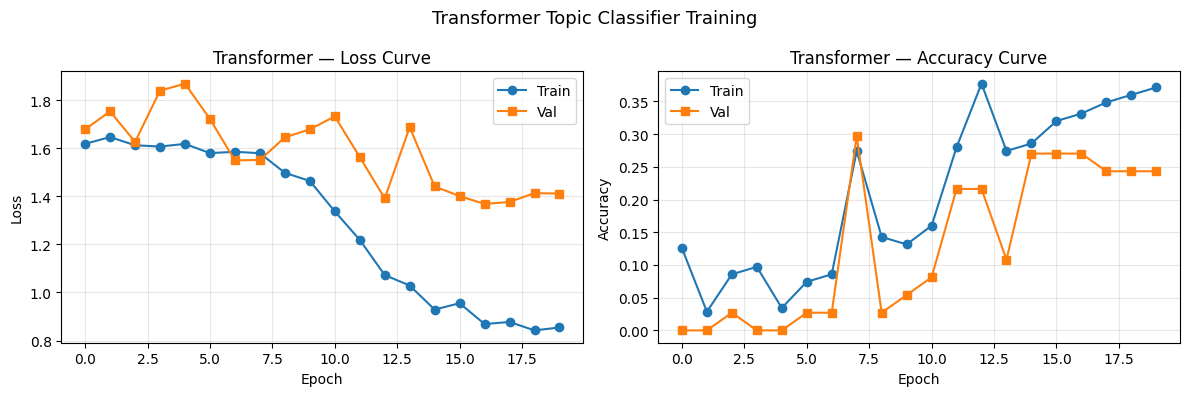

In [140]:

# Plot loss & accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tr_losses_cls, label='Train', marker='o')
axes[0].plot(val_losses_cls, label='Val',   marker='s')
axes[0].set_title('Transformer — Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(tr_accs_cls, label='Train', marker='o')
axes[1].plot(val_accs_cls, label='Val',  marker='s')
axes[1].set_title('Transformer — Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Transformer Topic Classifier Training', fontsize=13)
plt.tight_layout()
plt.savefig('models/transformer_curves.png', dpi=100)
plt.show()


### 3.4 Evaluation

Test Accuracy: 0.2368  |  Macro-F1: 0.2043


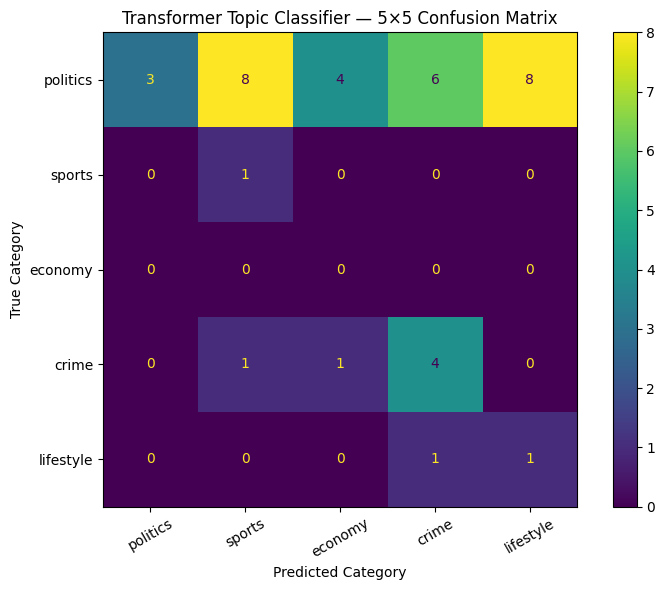

In [141]:
trans_model.eval()
all_preds_cls, all_true_cls = [], []
with torch.no_grad():
    for xb, yb in cls_test_loader:
        xb = xb.to(DEVICE)
        logits = trans_model(xb)
        all_preds_cls.extend(logits.argmax(1).cpu().tolist())
        all_true_cls.extend(yb.tolist())

test_acc_cls = accuracy_score(all_true_cls, all_preds_cls)
test_f1_cls  = f1_score(all_true_cls, all_preds_cls, average='macro', zero_division=0)
print(f"Test Accuracy: {test_acc_cls:.4f}  |  Macro-F1: {test_f1_cls:.4f}")

# Force all 5 labels even if some are missing in test split
all_label_ids = list(range(len(CAT5)))
cm_cls = confusion_matrix(all_true_cls, all_preds_cls, labels=all_label_ids)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_cls, display_labels=CAT5)
disp.plot(ax=ax, colorbar=True, xticks_rotation=30)
ax.set_title('Transformer Topic Classifier — 5×5 Confusion Matrix')
ax.set_xlabel('Predicted Category')
ax.set_ylabel('True Category')
plt.tight_layout()
plt.savefig('models/transformer_confusion.png', dpi=100)
plt.show()

### 3.5 Attention Weight Heatmaps

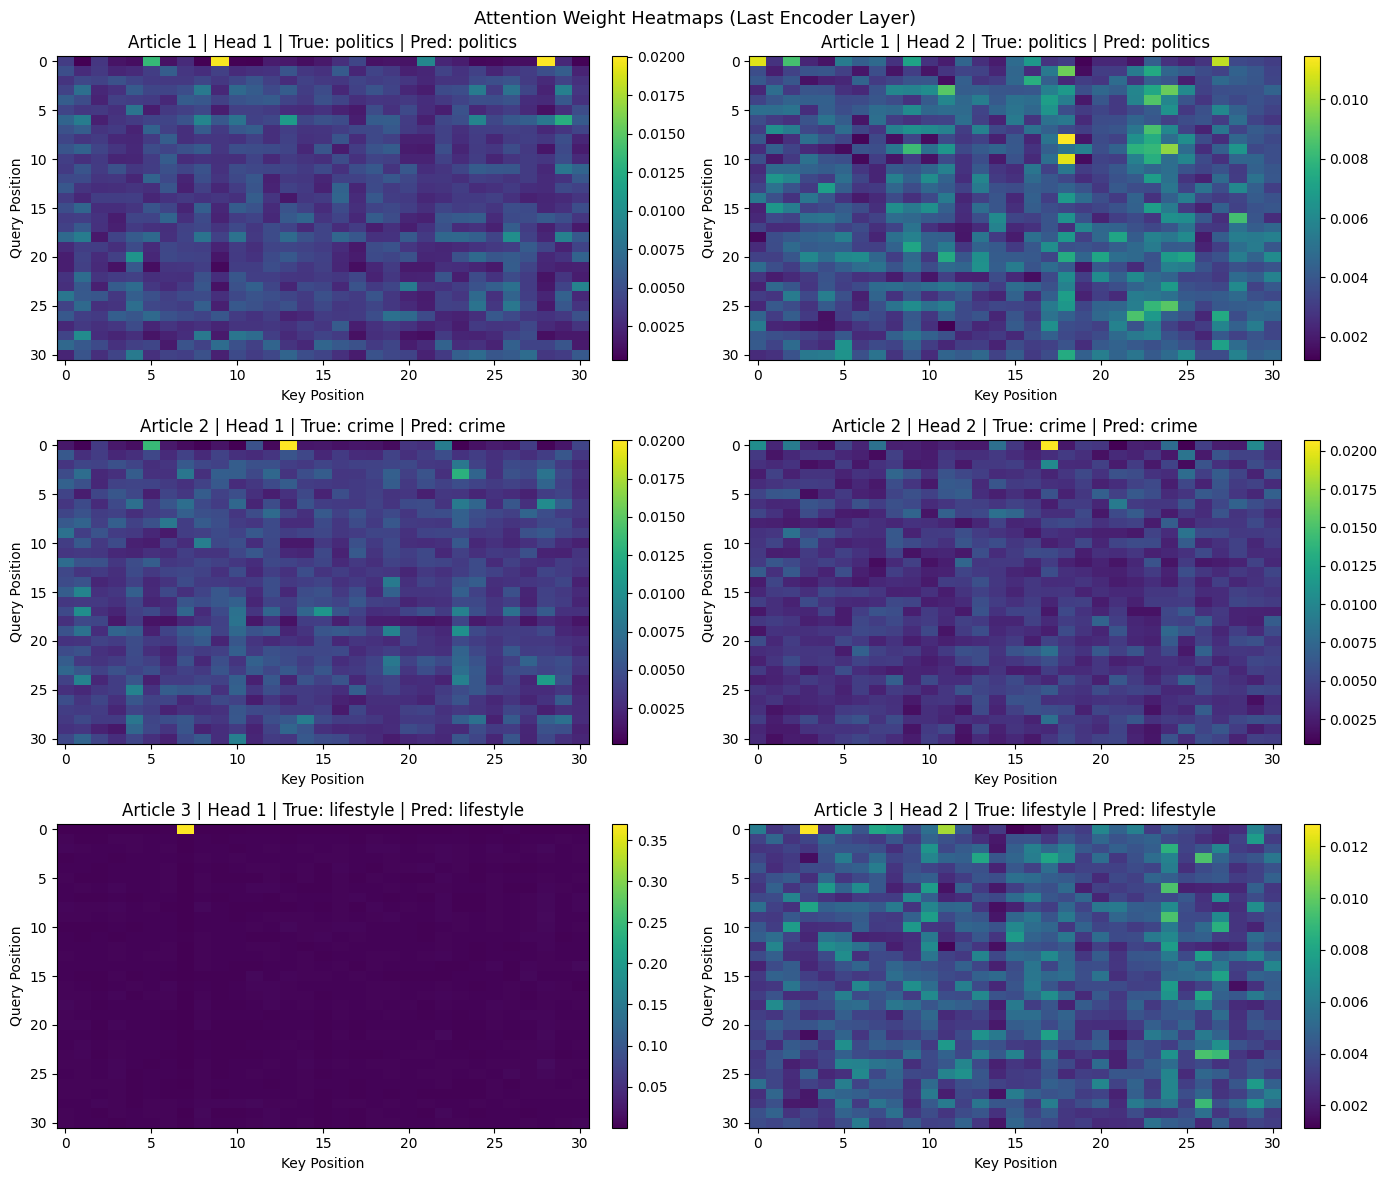

Heatmaps saved for 3 correctly classified article(s).


In [142]:
# Find up to 3 correctly classified test articles
correct_indices = [i for i, (p, t) in enumerate(zip(all_preds_cls, all_true_cls)) if p == t]

if len(correct_indices) == 0:
    print("⚠ No correctly classified test articles found.")
    print("  Rerun after fixing the transformer training (Cell 51).")
else:
    # Use up to 3; warn if fewer are available
    n_show = min(3, len(correct_indices))
    if n_show < 3:
        print(f"⚠ Only {n_show} correctly classified article(s) found — showing {n_show}.")
    selected = correct_indices[:n_show]

    test_x = torch.tensor([cls_test[i][0] for i in selected], dtype=torch.long).to(DEVICE)
    test_y = [cls_test[i][1] for i in selected]

    trans_model.eval()
    with torch.no_grad():
        logits, all_attns = trans_model(test_x, return_attn=True)

    SHOW_LEN = 30   # first 30 positions for readability
    fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
    if n_show == 1:
        axes = [axes]   # make iterable when only 1 row

    for row in range(n_show):
        for col, head_idx in enumerate([0, 1]):
            attn       = all_attns[-1][row, head_idx].cpu().numpy()  # (L+1, L+1)
            attn_slice = attn[:SHOW_LEN + 1, :SHOW_LEN + 1]
            ax = axes[row][col]
            im = ax.imshow(attn_slice, aspect='auto', cmap='viridis')
            ax.set_title(
                f'Article {row+1} | Head {head_idx+1} | '
                f'True: {CAT5[test_y[row]]} | '
                f'Pred: {CAT5[logits[row].argmax().item()]}'
            )
            ax.set_xlabel('Key Position')
            ax.set_ylabel('Query Position')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle('Attention Weight Heatmaps (Last Encoder Layer)', fontsize=13)
    plt.tight_layout()
    plt.savefig('models/attention_heatmaps.png', dpi=100)
    plt.show()
    print(f"Heatmaps saved for {n_show} correctly classified article(s).")